In [12]:
DATA_PATH = "Raisin_Dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print(df.shape)
df.head()

(900, 8)


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    average_precision_score, log_loss, cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

In [14]:
DATA_PATH = "Raisin_Dataset.xlsx"
df = pd.read_excel(DATA_PATH)
print(df.shape)
print(df.head(10))

(900, 8)
    Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524       442.246011       253.291155      0.819738       90546   
1  75166       406.690687       243.032436      0.801805       78789   
2  90856       442.267048       266.328318      0.798354       93717   
3  45928       286.540559       208.760042      0.684989       47336   
4  79408       352.190770       290.827533      0.564011       81463   
5  49242       318.125407       200.122120      0.777351       51368   
6  42492       310.146072       176.131449      0.823099       43904   
7  60952       332.455472       235.429835      0.706058       62329   
8  42256       323.189607       172.575926      0.845499       44743   
9  64380       366.964842       227.771615      0.784056       66125   

     Extent  Perimeter    Class  
0  0.758651   1184.040  Kecimen  
1  0.684130   1121.786  Kecimen  
2  0.637613   1208.575  Kecimen  
3  0.699599    844.162  Kecimen  
4  0.792772   1073.251  Keci

In [15]:
print(df.info())
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB
None
Area                 int64
MajorAxisLength    float64
MinorAxisLength    float64
Eccentricity       float64
ConvexArea           int64
Extent             float64
Perimeter          float64
Class               object
dtype: object
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter   

In [16]:
print(df.describe().T)
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True))

                 count          mean           std           min  \
Area             900.0  87804.127778  39002.111390  25387.000000   
MajorAxisLength  900.0    430.929950    116.035121    225.629541   
MinorAxisLength  900.0    254.488133     49.988902    143.710872   
Eccentricity     900.0      0.781542      0.090318      0.348730   
ConvexArea       900.0  91186.090000  40769.290132  26139.000000   
Extent           900.0      0.699508      0.053468      0.379856   
Perimeter        900.0   1165.906636    273.764315    619.074000   

                          25%           50%            75%            max  
Area             59348.000000  78902.000000  105028.250000  235047.000000  
MajorAxisLength    345.442898    407.803951     494.187014     997.291941  
MinorAxisLength    219.111126    247.848409     279.888575     492.275279  
Eccentricity         0.741766      0.798846       0.842571       0.962124  
ConvexArea       61513.250000  81651.000000  108375.750000  278217.000000  

In [17]:
FEATURES = [c for c in df.columns if c != "Class"]
TARGET = "Class"
X = df[FEATURES].values
le = LabelEncoder()
y = le.fit_transform(df[TARGET].values)
CLASS_NAMES = list(le.classes_)
print(FEATURES)
print(CLASS_NAMES)
print(np.bincount(y))

['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
['Besni', 'Kecimen']
[450 450]


In [18]:
summary_by_class = df.groupby(TARGET)[FEATURES].agg(["mean", "std", "min", "max"]).T
print(summary_by_class)

Class                         Besni        Kecimen
Area            mean  112194.788889   63413.466667
                std    39229.897872   17727.768795
                min    40702.000000   25387.000000
                max   235047.000000  180898.000000
MajorAxisLength mean     509.000652     352.859249
                std      105.771154      59.611494
                min      274.168954     225.629541
                max      997.291941     843.956653
MinorAxisLength mean     279.623674     229.352592
                std       50.763657      34.058657
                min      172.508389     143.710872
                max      492.275279     326.898724
Eccentricity    mean       0.821125       0.741960
                std        0.068277       0.092362
                min        0.500991       0.348730
                max        0.962124       0.923770
ConvexArea      mean  116675.824444   65696.355556
                std    40797.067805   19005.891848
                min    41924.00

In [19]:
skew_kurt = pd.DataFrame({
    "skewness": df[FEATURES].skew(),
    "kurtosis": df[FEATURES].kurtosis(),
})
print(skew_kurt)

shapiro_results = pd.DataFrame(
    [[f, *stats.shapiro(df.loc[df[TARGET] == c, f])] for c in CLASS_NAMES for f in FEATURES],
    columns=["feature", "shapiro_W", "shapiro_p"],
)
shapiro_results["class"] = [c for c in CLASS_NAMES for _ in FEATURES]
print(shapiro_results)

                 skewness  kurtosis
Area             1.175237  1.074073
MajorAxisLength  0.989544  1.326808
MinorAxisLength  0.800049  0.953915
Eccentricity    -1.327503  2.492121
ConvexArea       1.242904  1.427258
Extent          -1.151505  3.341384
Perimeter        1.017761  1.744706
            feature  shapiro_W     shapiro_p    class
0              Area   0.953428  1.035658e-10    Besni
1   MajorAxisLength   0.965919  1.017976e-08    Besni
2   MinorAxisLength   0.975067  5.835872e-07    Besni
3      Eccentricity   0.912269  1.759232e-15    Besni
4        ConvexArea   0.950171  3.570469e-11    Besni
5            Extent   0.939408  1.419015e-12    Besni
6         Perimeter   0.960175  1.105488e-09    Besni
7              Area   0.953859  1.196697e-10  Kecimen
8   MajorAxisLength   0.903184  2.600410e-16  Kecimen
9   MinorAxisLength   0.994317  9.281588e-02  Kecimen
10     Eccentricity   0.901902  2.006245e-16  Kecimen
11       ConvexArea   0.902536  2.280259e-16  Kecimen
12        

c:\Users\lavud\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\lavud\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\lavud\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\lavud\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

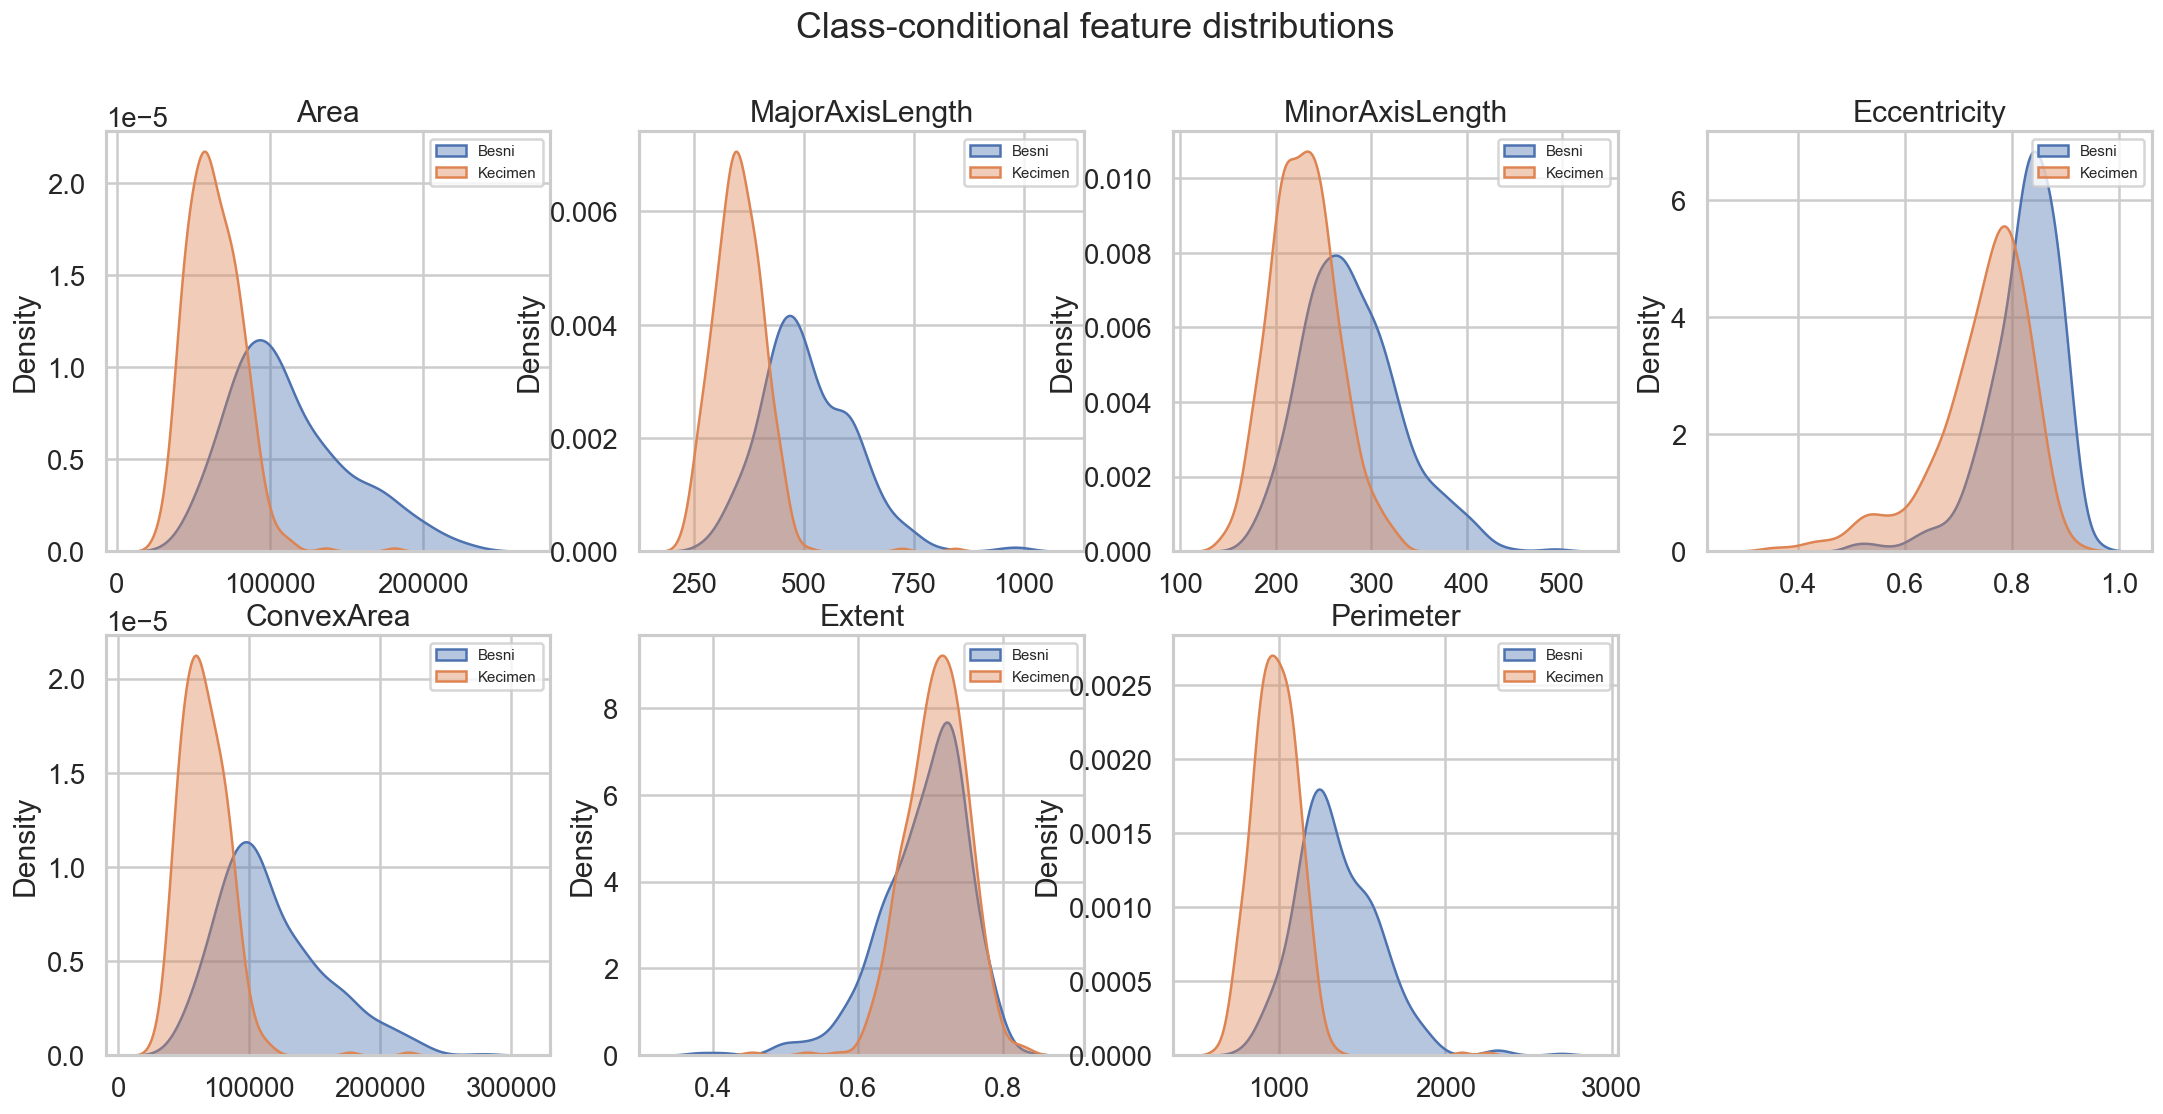

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, f in zip(axes.ravel(), FEATURES):
    for c in CLASS_NAMES:
        sns.kdeplot(df.loc[df[TARGET] == c, f], ax=ax, fill=True, alpha=0.4, label=c)
    ax.set_title(f)
    ax.set_xlabel("")
    ax.legend(fontsize=9)
axes.ravel()[-1].axis("off")
fig.suptitle("Class-conditional feature distributions")
fig.savefig(f"{OUTDIR}/01_feature_distributions.png")
plt.show()

TypeError: Axes.boxplot() got an unexpected keyword argument 'legend'

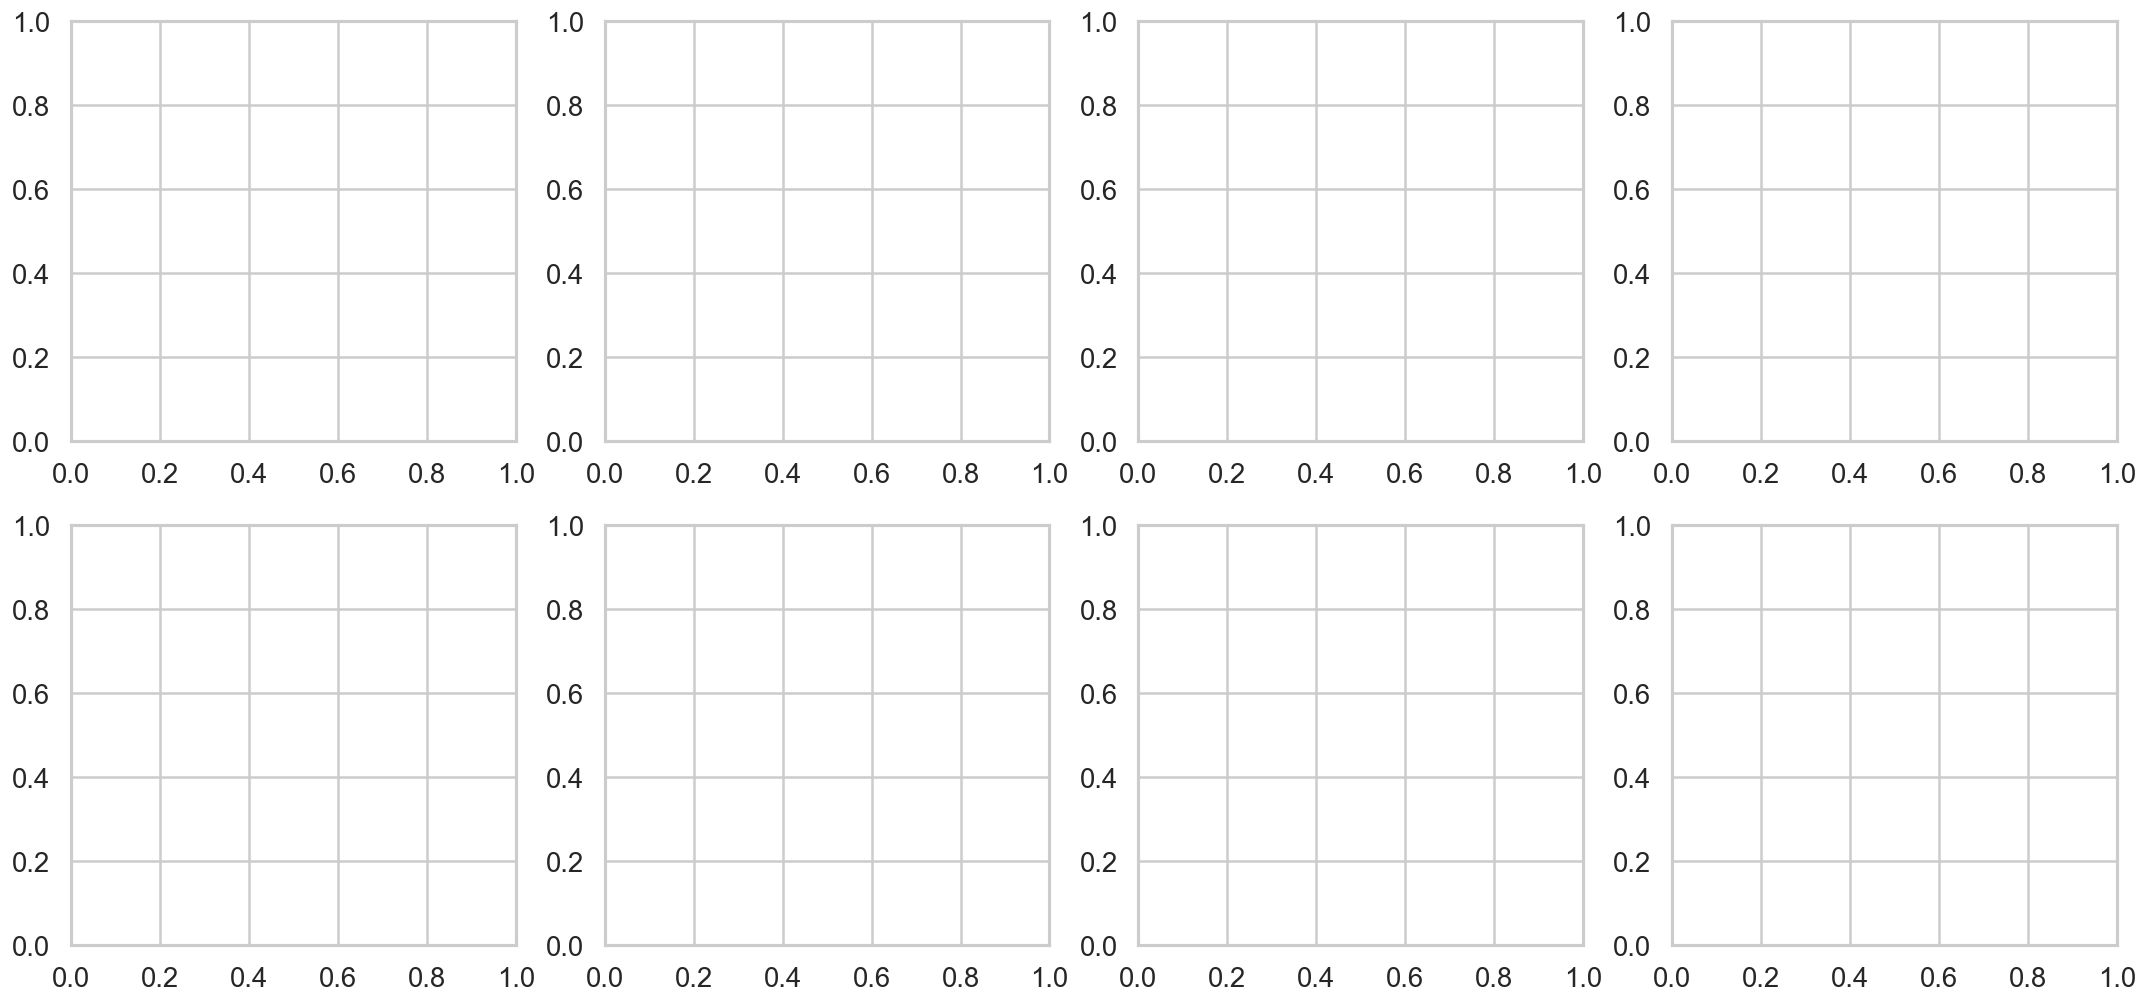

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, f in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=df, x=TARGET, y=f, ax=ax, hue=TARGET, legend=False)
    ax.set_title(f)
    ax.set_xlabel("")
axes.ravel()[-1].axis("off")
fig.suptitle("Feature boxplots by class")
fig.savefig(f"{OUTDIR}/02_boxplots.png")
plt.show()

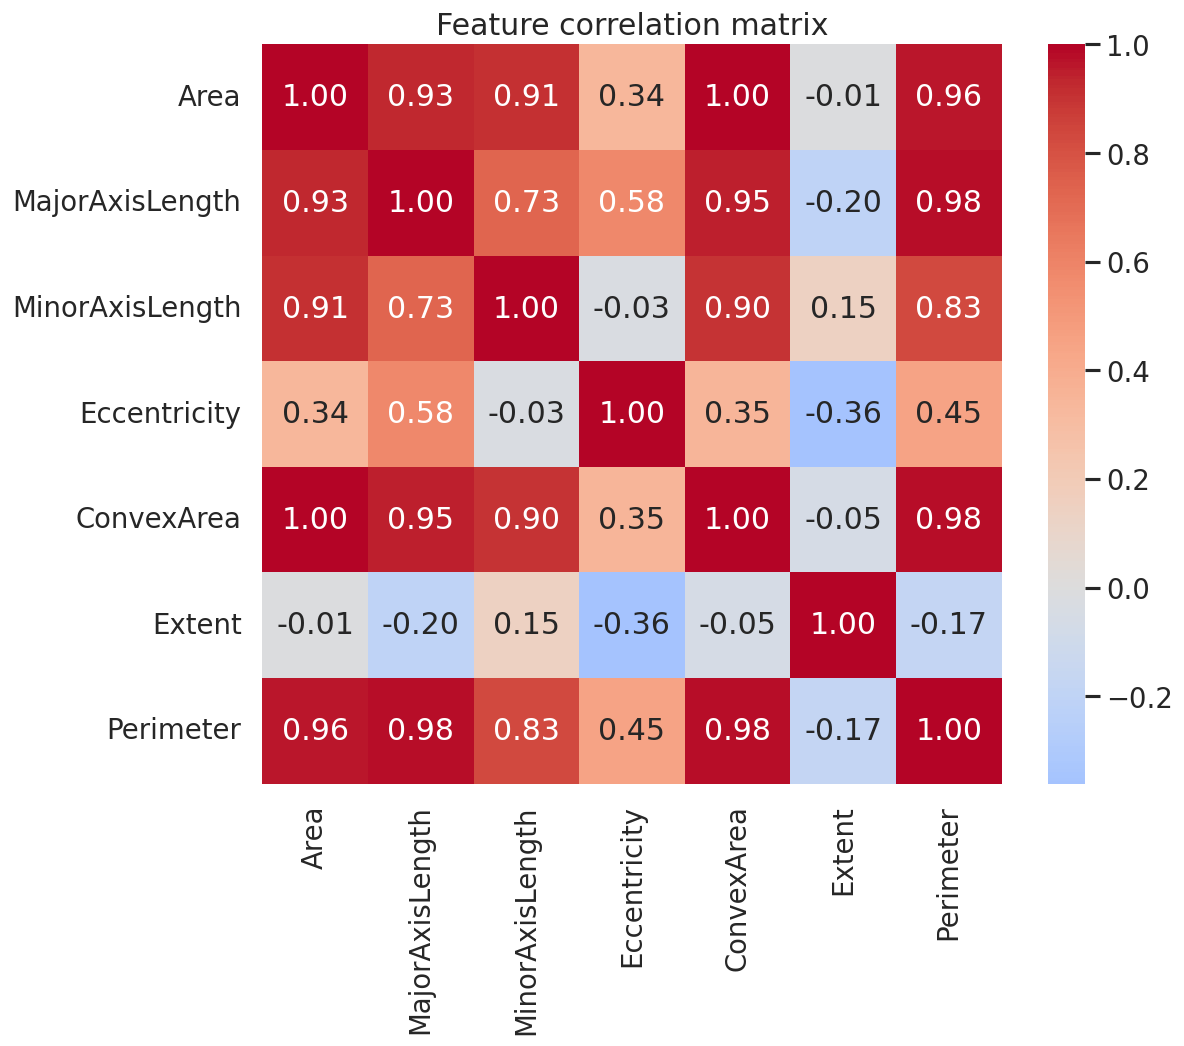

                     Area  MajorAxisLength  MinorAxisLength  Eccentricity  \
Area             1.000000         0.932774         0.906650      0.336107   
MajorAxisLength  0.932774         1.000000         0.728030      0.583608   
MinorAxisLength  0.906650         0.728030         1.000000     -0.027683   
Eccentricity     0.336107         0.583608        -0.027683      1.000000   
ConvexArea       0.995920         0.945031         0.895651      0.348210   
Extent          -0.013499        -0.203866         0.145322     -0.361061   
Perimeter        0.961352         0.977978         0.827417      0.447845   

                 ConvexArea    Extent  Perimeter  
Area               0.995920 -0.013499   0.961352  
MajorAxisLength    0.945031 -0.203866   0.977978  
MinorAxisLength    0.895651  0.145322   0.827417  
Eccentricity       0.348210 -0.361061   0.447845  
ConvexArea         1.000000 -0.054802   0.976612  
Extent            -0.054802  1.000000  -0.173449  
Perimeter          0.97661

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Feature correlation matrix")
fig.savefig(f"{OUTDIR}/03_correlation_heatmap.png")
plt.show()
print(df[FEATURES].corr())

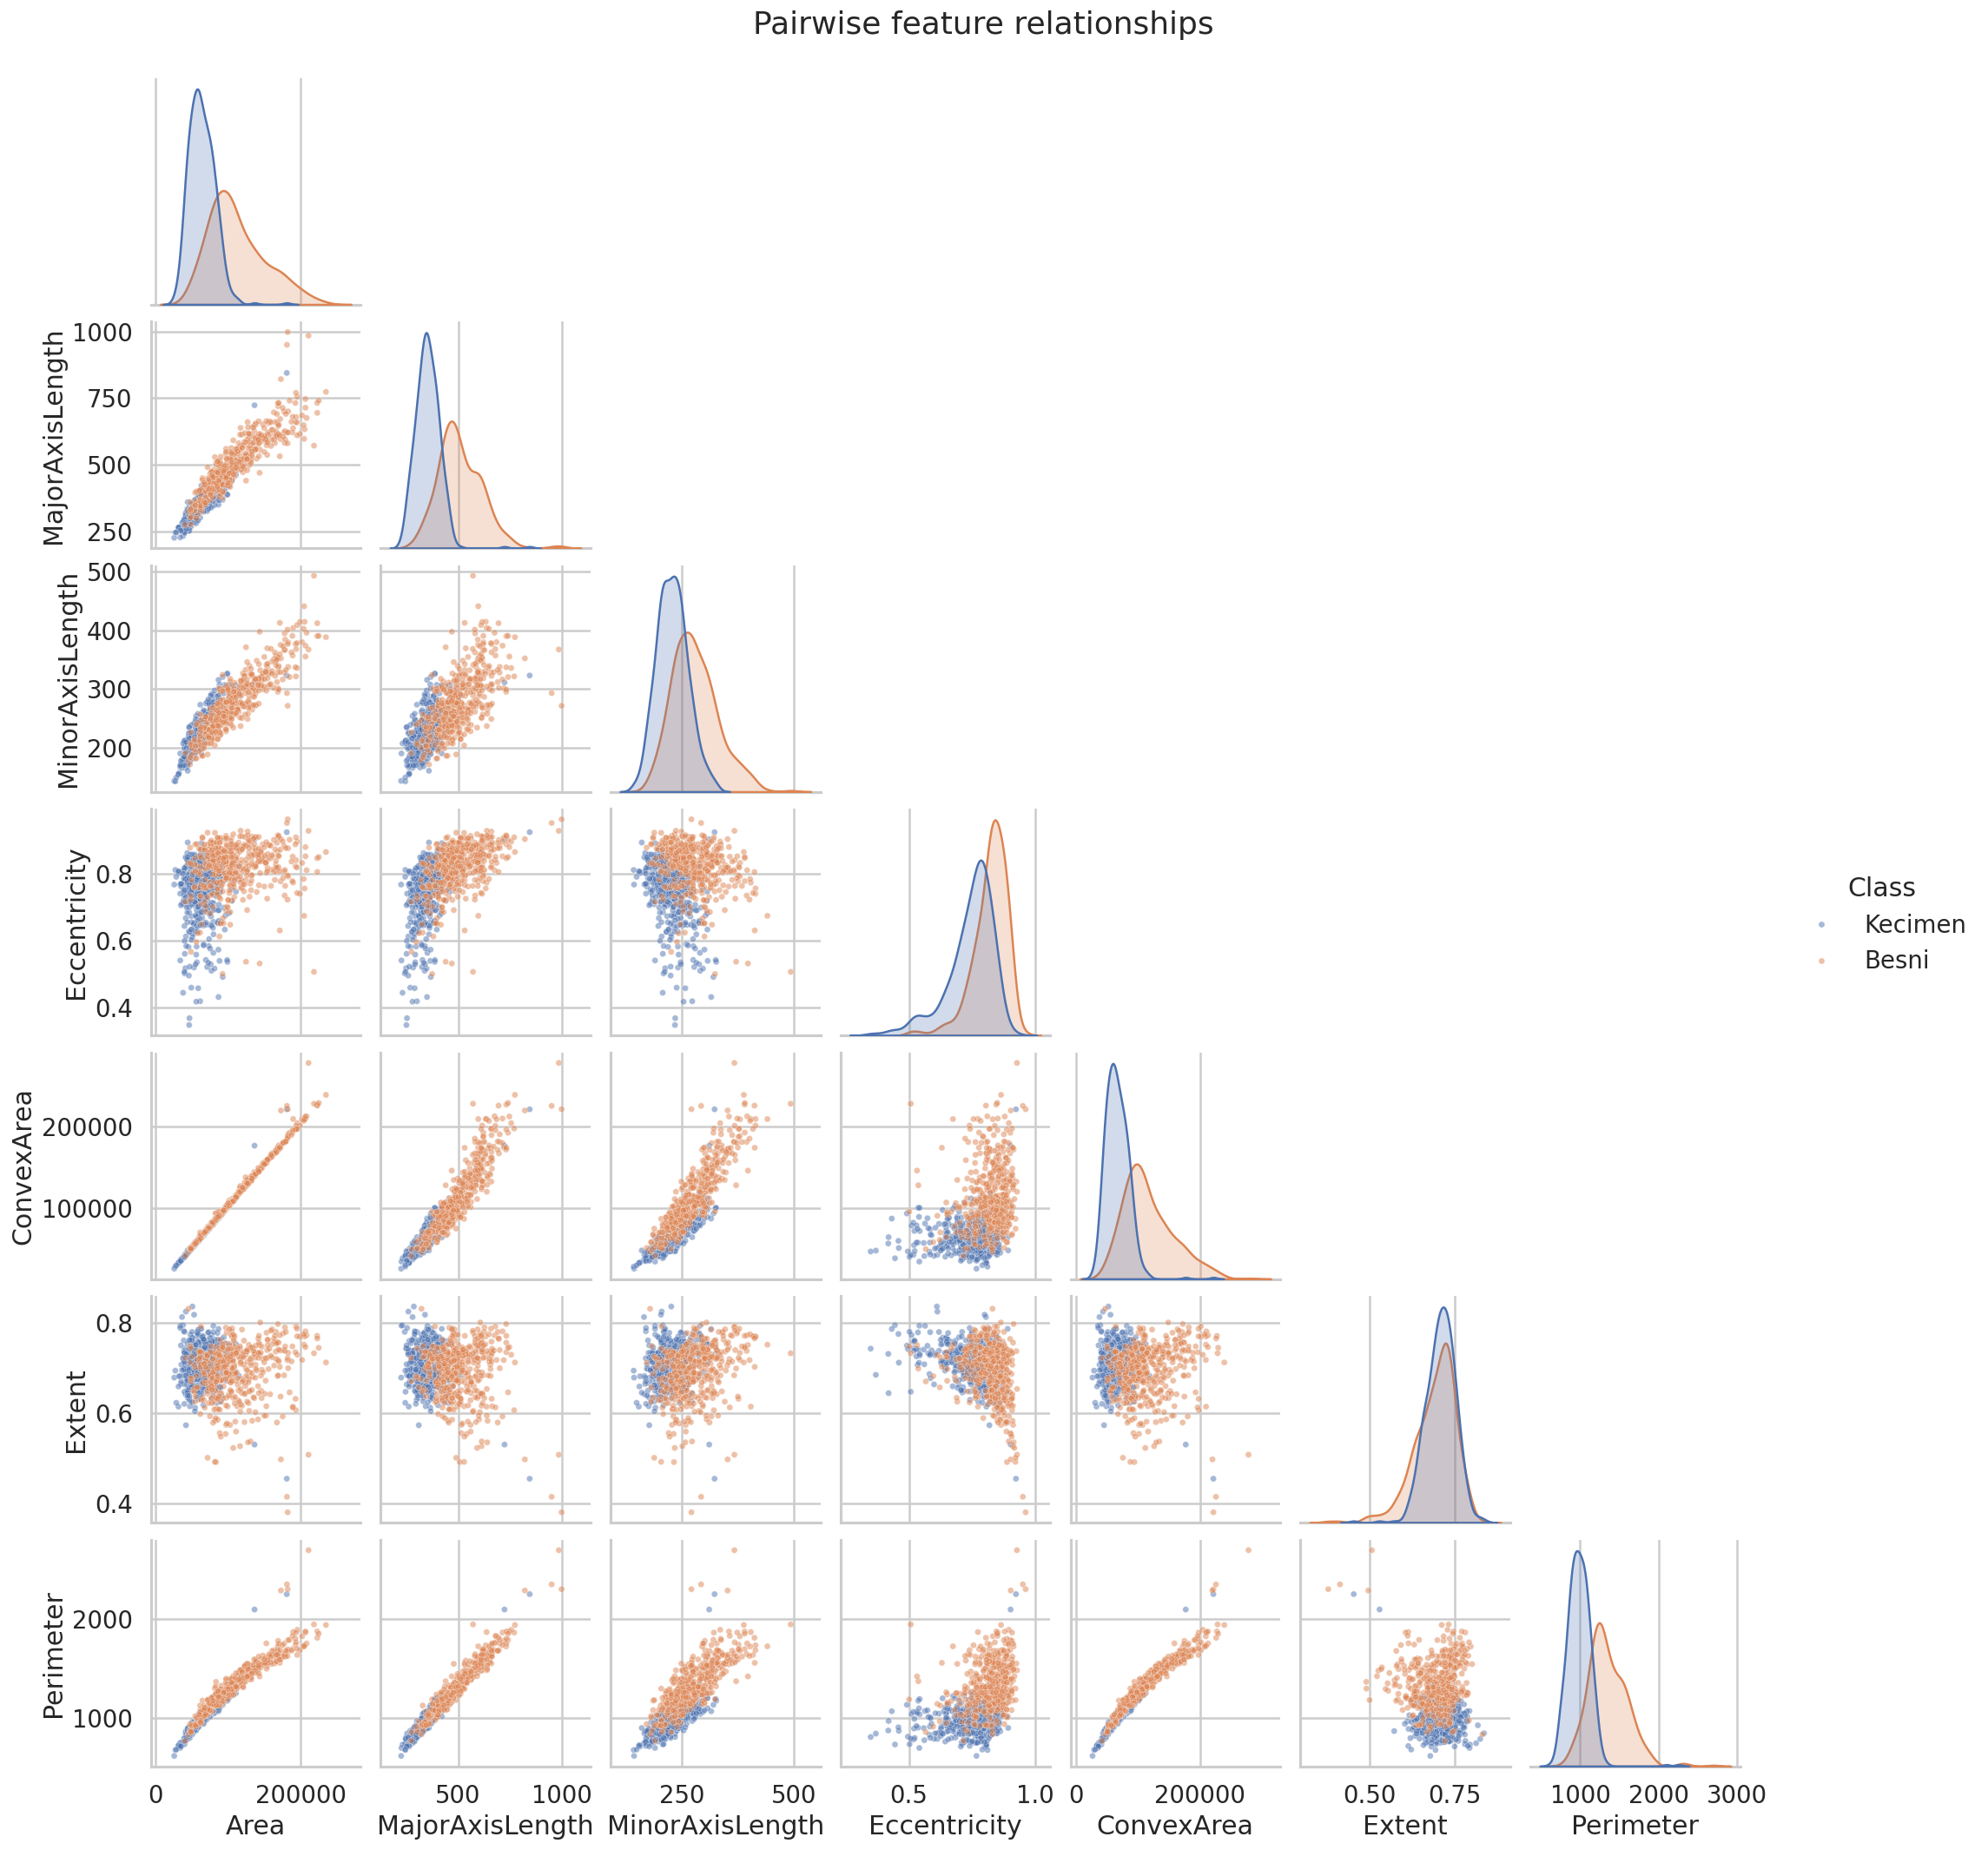

In [ ]:
pair = sns.pairplot(df, hue=TARGET, corner=True, plot_kws={"alpha": 0.5, "s": 18})
pair.figure.suptitle("Pairwise feature relationships", y=1.02)
pair.figure.savefig(f"{OUTDIR}/04_pairplot.png")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(X_train.shape, X_test.shape)
print(np.bincount(y_train), np.bincount(y_test))
print(pd.DataFrame(X_train_s, columns=FEATURES).describe().T[["mean", "std"]])

(720, 7) (180, 7)
[360 360] [90 90]
                         mean       std
Area            -1.184238e-16  1.000695
MajorAxisLength  1.401348e-15  1.000695
MinorAxisLength -5.470932e-15  1.000695
Eccentricity     7.579123e-15  1.000695
ConvexArea       1.295260e-16  1.000695
Extent           1.300935e-14  1.000695
Perimeter        2.224147e-15  1.000695


LDA Best parameters: {'lda__shrinkage': np.float64(0.05)}
LDA Best CV score: 0.8639
QDA Best parameters: {'qda__reg_param': np.float64(0.0)}
QDA Best CV score: 0.8597


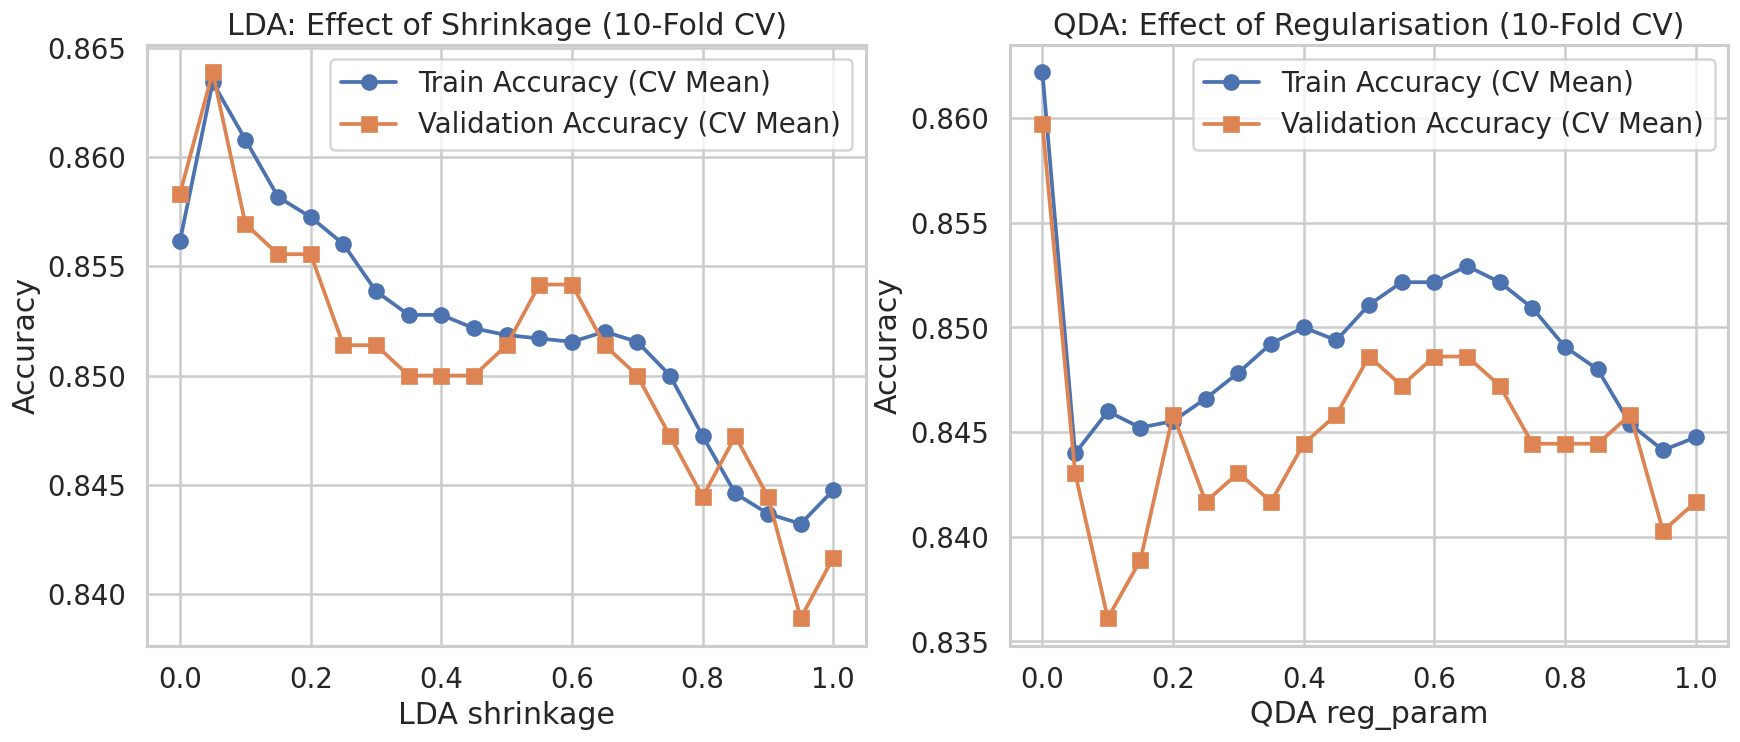

In [ ]:
from sklearn.pipeline import Pipeline

# Define pipelines for LDA and QDA with StandardScaler
lda_pipeline_tuning = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr"))
])

qda_pipeline_tuning = Pipeline([
    ("scaler", StandardScaler()),
    ("qda", QuadraticDiscriminantAnalysis())
])

# Define parameter grids for GridSearchCV
lda_param_grid = {
    "lda__shrinkage": np.linspace(0, 1, 21)
}

qda_param_grid = {
    "qda__reg_param": np.linspace(0, 1, 21)
}

# Set up StratifiedKFold for cross-validation on training data
strat_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# GridSearchCV for LDA
lda_grid = GridSearchCV(
    lda_pipeline_tuning,
    lda_param_grid,
    cv=strat_kfold,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)
lda_grid.fit(X_train, y_train) # Fit on unscaled X_train, pipeline handles scaling

# GridSearchCV for QDA
qda_grid = GridSearchCV(
    qda_pipeline_tuning,
    qda_param_grid,
    cv=strat_kfold,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)
qda_grid.fit(X_train, y_train) # Fit on unscaled X_train, pipeline handles scaling

print("LDA Best parameters:", lda_grid.best_params_)
print("LDA Best CV score:", lda_grid.best_score_.round(4))
print("QDA Best parameters:", qda_grid.best_params_)
print("QDA Best CV score:", qda_grid.best_score_.round(4))

# Extract results for plotting
lda_cv_results = pd.DataFrame(lda_grid.cv_results_)
qda_cv_results = pd.DataFrame(qda_grid.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

# Plot LDA sensitivity using CV results
axes[0].plot(lda_cv_results["param_lda__shrinkage"], lda_cv_results["mean_train_score"], "o-", label="Train Accuracy (CV Mean)")
axes[0].plot(lda_cv_results["param_lda__shrinkage"], lda_cv_results["mean_test_score"], "s-", label="Validation Accuracy (CV Mean)")
axes[0].set_xlabel("LDA shrinkage")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("LDA: Effect of Shrinkage (10-Fold CV)")
axes[0].legend()

# Plot QDA sensitivity using CV results
axes[1].plot(qda_cv_results["param_qda__reg_param"], qda_cv_results["mean_train_score"], "o-", label="Train Accuracy (CV Mean)")
axes[1].plot(qda_cv_results["param_qda__reg_param"], qda_cv_results["mean_test_score"], "s-", label="Validation Accuracy (CV Mean)")
axes[1].set_xlabel("QDA reg_param")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("QDA: Effect of Regularisation (10-Fold CV)")
axes[1].legend()

fig.savefig(f"{OUTDIR}/18_hyperparameter_sensitivity_cv.png")
plt.show()

In [ ]:
lda = LinearDiscriminantAnalysis(solver="svd", store_covariance=True)
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
lda.fit(X_train_s, y_train)
qda.fit(X_train_s, y_train)

y_pred_lda = lda.predict(X_test_s)
y_pred_qda = qda.predict(X_test_s)
y_prob_lda = lda.predict_proba(X_test_s)[:, 1]
y_prob_qda = qda.predict_proba(X_test_s)[:, 1]
y_pred_lda_tr = lda.predict(X_train_s)
y_pred_qda_tr = qda.predict(X_train_s)
y_prob_lda_tr = lda.predict_proba(X_train_s)[:, 1]
y_prob_qda_tr = qda.predict_proba(X_train_s)[:, 1]

In [ ]:
print(pd.DataFrame(lda.means_, index=CLASS_NAMES, columns=FEATURES))
print(lda.priors_)
print(pd.DataFrame(lda.coef_, columns=FEATURES, index=["coefficients"]))
print(lda.intercept_)
print(lda.explained_variance_ratio_)
print(pd.DataFrame(lda.covariance_, index=FEATURES, columns=FEATURES))

             Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
Besni    0.632994         0.679764         0.508266      0.444971    0.633704   
Kecimen -0.632994        -0.679764        -0.508266     -0.444971   -0.633704   

           Extent  Perimeter  
Besni   -0.151478   0.674406  
Kecimen  0.151478  -0.674406  
[0.5 0.5]
                   Area  MajorAxisLength  MinorAxisLength  Eccentricity  \
coefficients -12.740204         2.728383         0.323489     -0.703033   

              ConvexArea    Extent  Perimeter  
coefficients      16.692  0.026846  -9.497859  
[2.30926389e-14]
[1.]
                     Area  MajorAxisLength  MinorAxisLength  Eccentricity  \
Area             0.599318         0.502499         0.582430      0.063242   
MajorAxisLength  0.502499         0.537920         0.379597      0.286218   
MinorAxisLength  0.582430         0.379597         0.741665     -0.249936   
Eccentricity     0.063242         0.286218        -0.249936      0.802000   

In [ ]:
print(pd.DataFrame(qda.means_, index=CLASS_NAMES, columns=FEATURES))
print(qda.priors_)
for name, cov in zip(CLASS_NAMES, qda.covariance_):
    print(name)
    print(pd.DataFrame(cov, index=FEATURES, columns=FEATURES))
    print(np.linalg.det(cov), np.linalg.cond(cov))

             Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
Besni    0.632994         0.679764         0.508266      0.444971    0.633704   
Kecimen -0.632994        -0.679764        -0.508266     -0.444971   -0.633704   

           Extent  Perimeter  
Besni   -0.151478   0.674406  
Kecimen  0.151478  -0.674406  
[0.5 0.5]
Besni
                     Area  MajorAxisLength  MinorAxisLength  Eccentricity  \
Area             1.013290         0.825206         0.905275      0.109630   
MajorAxisLength  0.825206         0.853229         0.572319      0.355544   
MinorAxisLength  0.905275         0.572319         1.017678     -0.214956   
Eccentricity     0.109630         0.355544        -0.214956      0.573120   
ConvexArea       1.004996         0.846457         0.887813      0.125029   
Extent           0.168431        -0.132495         0.342984     -0.283063   
Perimeter        0.859379         0.812202         0.698689      0.212047   

                 ConvexArea   

In [ ]:
cov_pooled = lda.covariance_
cov_diff = qda.covariance_[0] - qda.covariance_[1]
frob_diff = np.linalg.norm(cov_diff, ord="fro") / np.linalg.norm(cov_pooled, ord="fro")
print(frob_diff)

n_k = np.bincount(y_train)
p = X_train_s.shape[1]
k = len(CLASS_NAMES)
pooled = sum((n_k[i] - 1) * qda.covariance_[i] for i in range(k)) / (n_k.sum() - k)
M = (n_k.sum() - k) * np.log(np.linalg.det(pooled)) - sum(
    (n_k[i] - 1) * np.log(np.linalg.det(qda.covariance_[i])) for i in range(k)
)
c1 = (sum(1 / (n_k[i] - 1) for i in range(k)) - 1 / (n_k.sum() - k)) * (2 * p**2 + 3 * p - 1) / (6 * (p + 1) * (k - 1))
box_m_stat = M * (1 - c1)
box_df = p * (p + 1) * (k - 1) / 2
box_p = 1 - stats.chi2.cdf(box_m_stat, box_df)
print(M, box_m_stat, box_df, box_p)

1.0712512280587971
2156.530729823364 2134.3797352099273 28.0 0.0


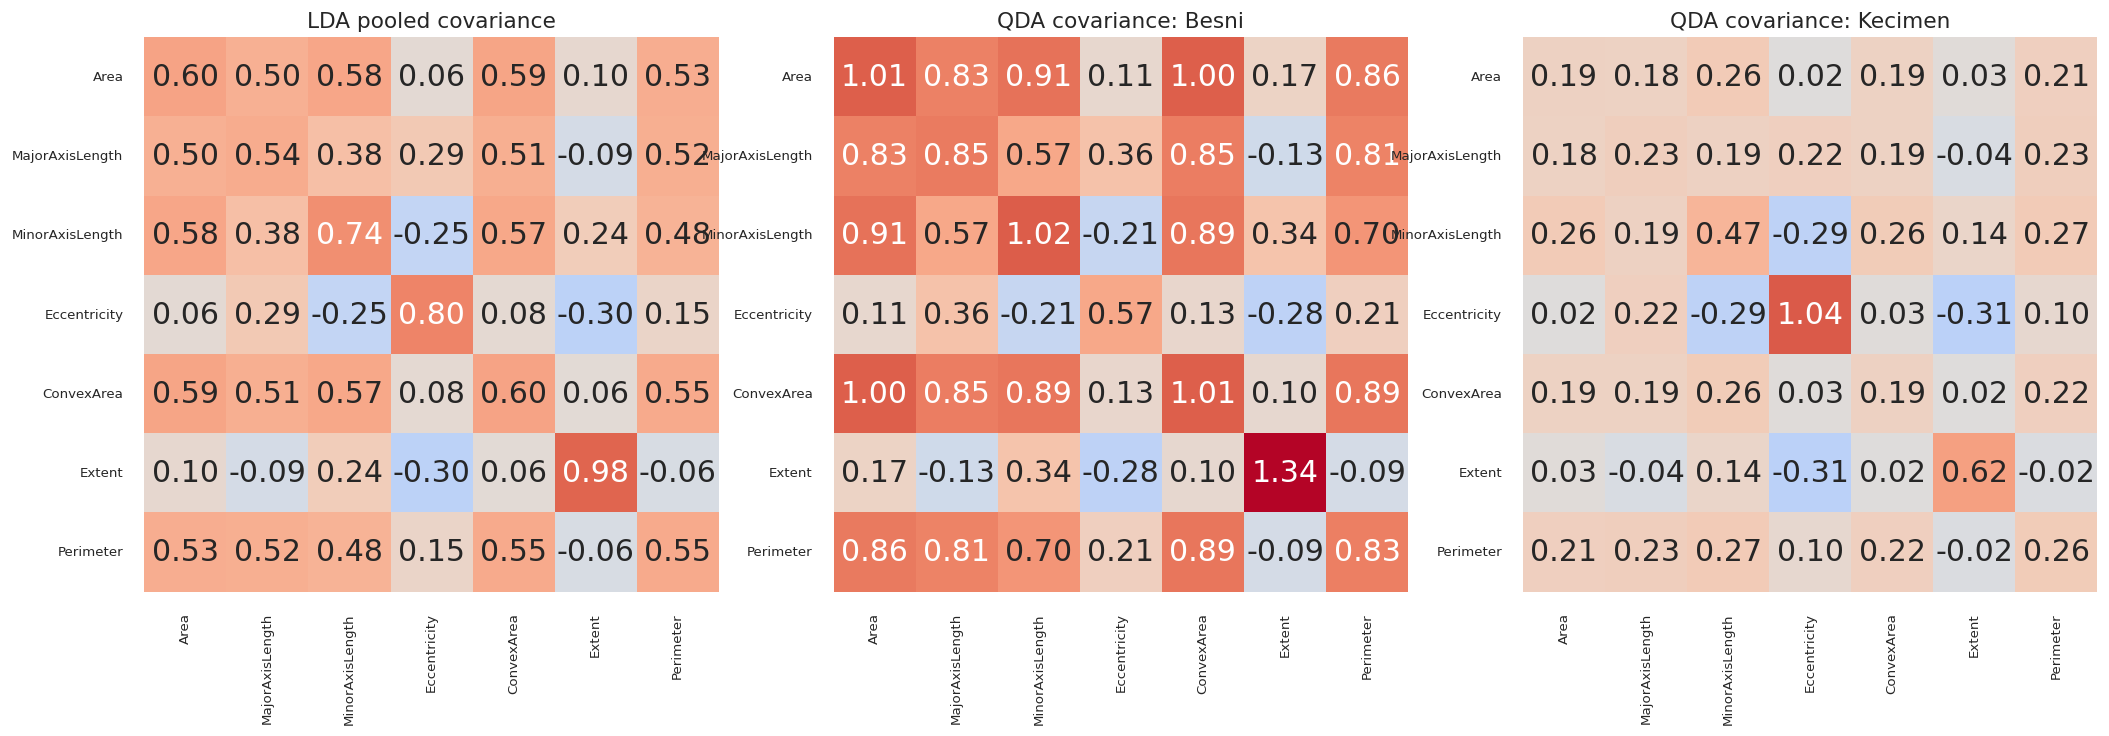

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
mats = [cov_pooled, qda.covariance_[0], qda.covariance_[1]]
titles = ["LDA pooled covariance", f"QDA covariance: {CLASS_NAMES[0]}", f"QDA covariance: {CLASS_NAMES[1]}"]
vmax = max(np.abs(m).max() for m in mats)
for ax, m, t in zip(axes, mats, titles):
    sns.heatmap(m, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-vmax, vmax=vmax,
                xticklabels=FEATURES, yticklabels=FEATURES, ax=ax, cbar=False)
    ax.set_title(t, fontsize=13)
    ax.tick_params(labelsize=8)
fig.savefig(f"{OUTDIR}/05_covariance_matrices.png")
plt.show()

In [ ]:
def evaluate(name, split, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Split": split,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
        "Cohen Kappa": cohen_kappa_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

# Get the best estimators from GridSearchCV
best_lda = lda_grid.best_estimator_
best_qda = qda_grid.best_estimator_

# Predictions for the best LDA model
y_pred_lda_tr = best_lda.predict(X_train)
y_prob_lda_tr = best_lda.predict_proba(X_train)[:, 1]
y_pred_lda = best_lda.predict(X_test)
y_prob_lda = best_lda.predict_proba(X_test)[:, 1]

# Predictions for the best QDA model
y_pred_qda_tr = best_qda.predict(X_train)
y_prob_qda_tr = best_qda.predict_proba(X_train)[:, 1]
y_pred_qda = best_qda.predict(X_test)
y_prob_qda = best_qda.predict_proba(X_test)[:, 1]

results = pd.DataFrame([
    evaluate("LDA (Tuned)", "Train", y_train, y_pred_lda_tr, y_prob_lda_tr),
    evaluate("LDA (Tuned)", "FINAL TEST", y_test, y_pred_lda, y_prob_lda),
    evaluate("QDA (Tuned)", "Train", y_train, y_pred_qda_tr, y_prob_qda_tr),
    evaluate("QDA (Tuned)", "FINAL TEST", y_test, y_pred_qda, y_prob_qda),
])
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
print(results.round(4))
results.round(4).to_csv("results_metrics_tuned.csv", index=False)

         Model       Split  Accuracy  Balanced Acc  Precision  Recall      F1  ROC-AUC  PR-AUC  Log Loss  Cohen Kappa     MCC
0  LDA (Tuned)       Train    0.8639        0.8639     0.8394  0.9000  0.8686   0.9279  0.9141    0.3495       0.7278  0.7297
1  LDA (Tuned)  FINAL TEST    0.8833        0.8833     0.8416  0.9444  0.8901   0.9144  0.8952    0.4104       0.7667  0.7725
2  QDA (Tuned)       Train    0.8639        0.8639     0.8090  0.9528  0.8750   0.9289  0.9114    0.6342       0.7278  0.7396
3  QDA (Tuned)  FINAL TEST    0.8556        0.8556     0.7857  0.9778  0.8713   0.9225  0.9007    0.8337       0.7111  0.7334


In [ ]:
slide_table = results[results["Split"] == "FINAL TEST"][["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
print(slide_table.round(3).to_string(index=False))
print(slide_table.round(3).to_latex(index=False))

      Model  Accuracy  Precision  Recall    F1  ROC-AUC
LDA (Tuned)     0.883      0.842   0.944 0.890    0.914
QDA (Tuned)     0.856      0.786   0.978 0.871    0.922
\begin{tabular}{lrrrrr}
\toprule
Model & Accuracy & Precision & Recall & F1 & ROC-AUC \\
\midrule
LDA (Tuned) & 0.883000 & 0.842000 & 0.944000 & 0.890000 & 0.914000 \\
QDA (Tuned) & 0.856000 & 0.786000 & 0.978000 & 0.871000 & 0.922000 \\
\bottomrule
\end{tabular}



In [ ]:
overfit_gap = pd.DataFrame({
    "Model": ["LDA (Tuned)", "QDA (Tuned)"], # Updated model names
    "Train Acc": [accuracy_score(y_train, y_pred_lda_tr), accuracy_score(y_train, y_pred_qda_tr)],
    "Test Acc": [accuracy_score(y_test, y_pred_lda), accuracy_score(y_test, y_pred_qda)],
})
overfit_gap["Gap"] = overfit_gap["Train Acc"] - overfit_gap["Test Acc"]
print(overfit_gap.round(4))

         Model  Train Acc  Test Acc     Gap
0  LDA (Tuned)     0.8639    0.8833 -0.0194
1  QDA (Tuned)     0.8639    0.8556  0.0083


In [ ]:
print(classification_report(y_test, y_pred_lda, target_names=CLASS_NAMES, digits=4))
print(classification_report(y_test, y_pred_qda, target_names=CLASS_NAMES, digits=4))

              precision    recall  f1-score   support

       Besni     0.9367    0.8222    0.8757        90
     Kecimen     0.8416    0.9444    0.8901        90

    accuracy                         0.8833       180
   macro avg     0.8891    0.8833    0.8829       180
weighted avg     0.8891    0.8833    0.8829       180

              precision    recall  f1-score   support

       Besni     0.9706    0.7333    0.8354        90
     Kecimen     0.7857    0.9778    0.8713        90

    accuracy                         0.8556       180
   macro avg     0.8782    0.8556    0.8534       180
weighted avg     0.8782    0.8556    0.8534       180



[[74 16]
 [ 5 85]]
[[66 24]
 [ 2 88]]


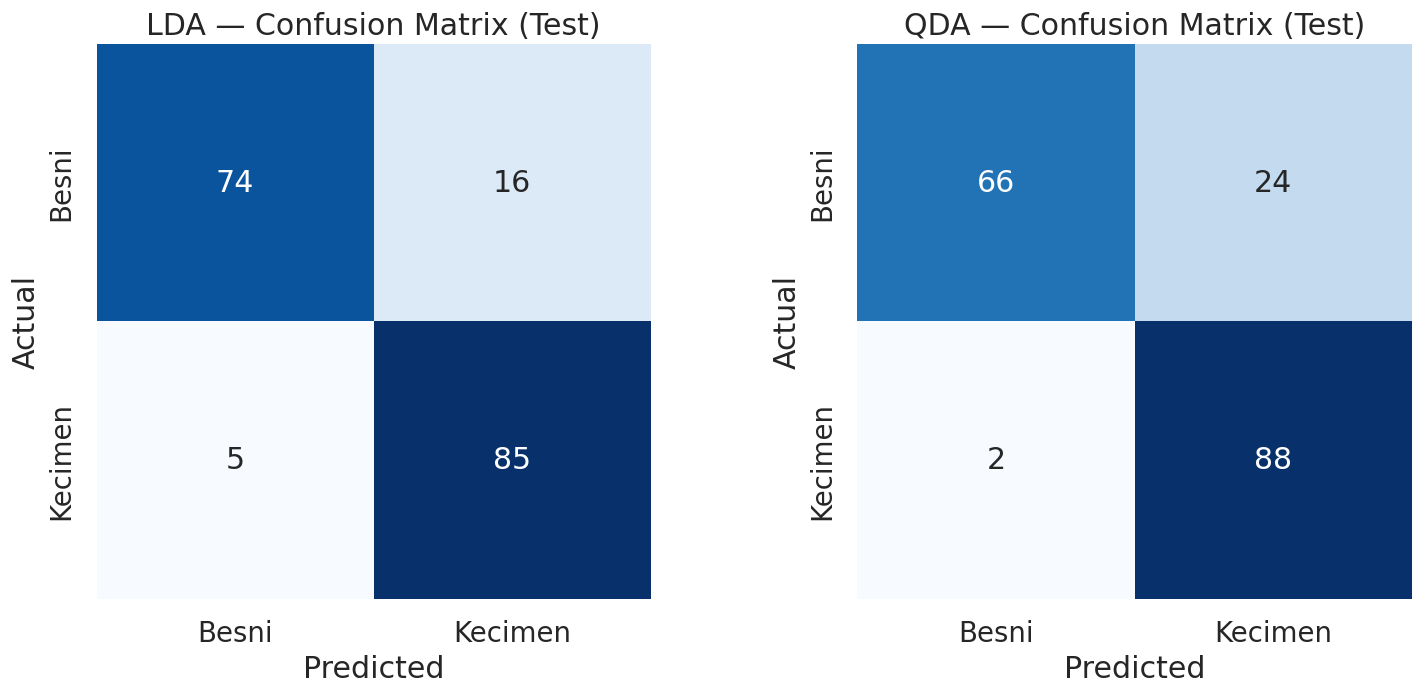

In [ ]:
cm_lda = confusion_matrix(y_test, y_pred_lda)
cm_qda = confusion_matrix(y_test, y_pred_qda)
print(cm_lda)
print(cm_qda)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, cm, title in zip(axes, [cm_lda, cm_qda], ["LDA", "QDA"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, annot_kws={"size": 18})
    ax.set_title(f"{title} — Confusion Matrix (Test)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig.savefig(f"{OUTDIR}/06_confusion_matrices.png")
plt.show()

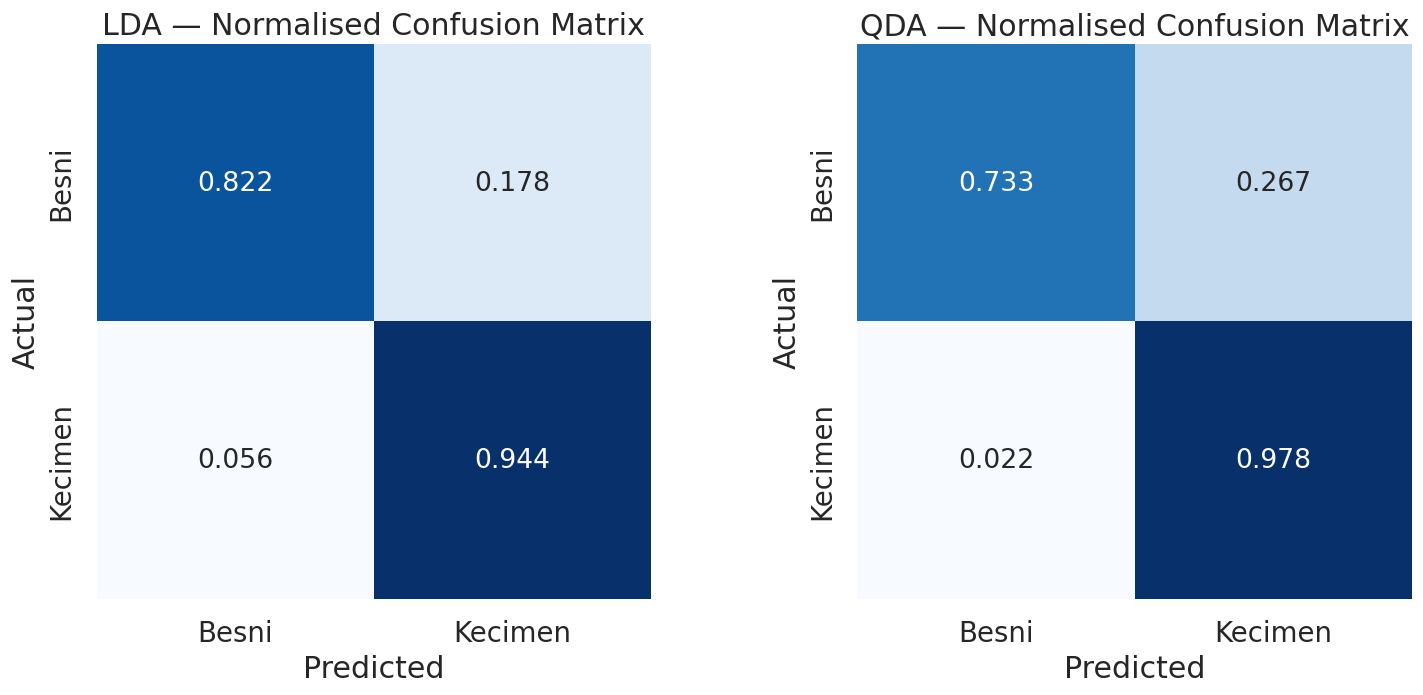

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, cm, title in zip(axes, [cm_lda, cm_qda], ["LDA", "QDA"]):
    sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".3f", cmap="Blues", cbar=False,
                square=True, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, annot_kws={"size": 16})
    ax.set_title(f"{title} — Normalised Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig.savefig(f"{OUTDIR}/07_confusion_matrices_normalised.png")
plt.show()

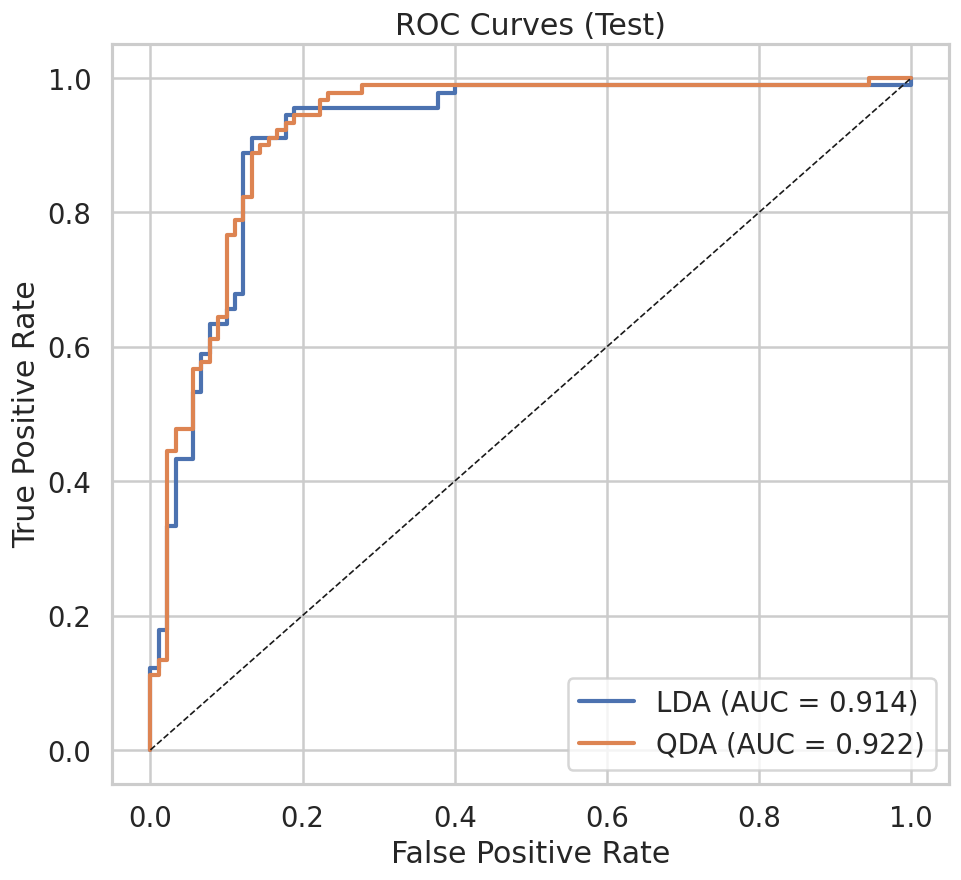

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))
for name, prob in [("LDA", y_prob_lda), ("QDA", y_prob_qda)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2.5, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (Test)")
ax.legend(loc="lower right")
fig.savefig(f"{OUTDIR}/08_roc_curves.png")
plt.show()

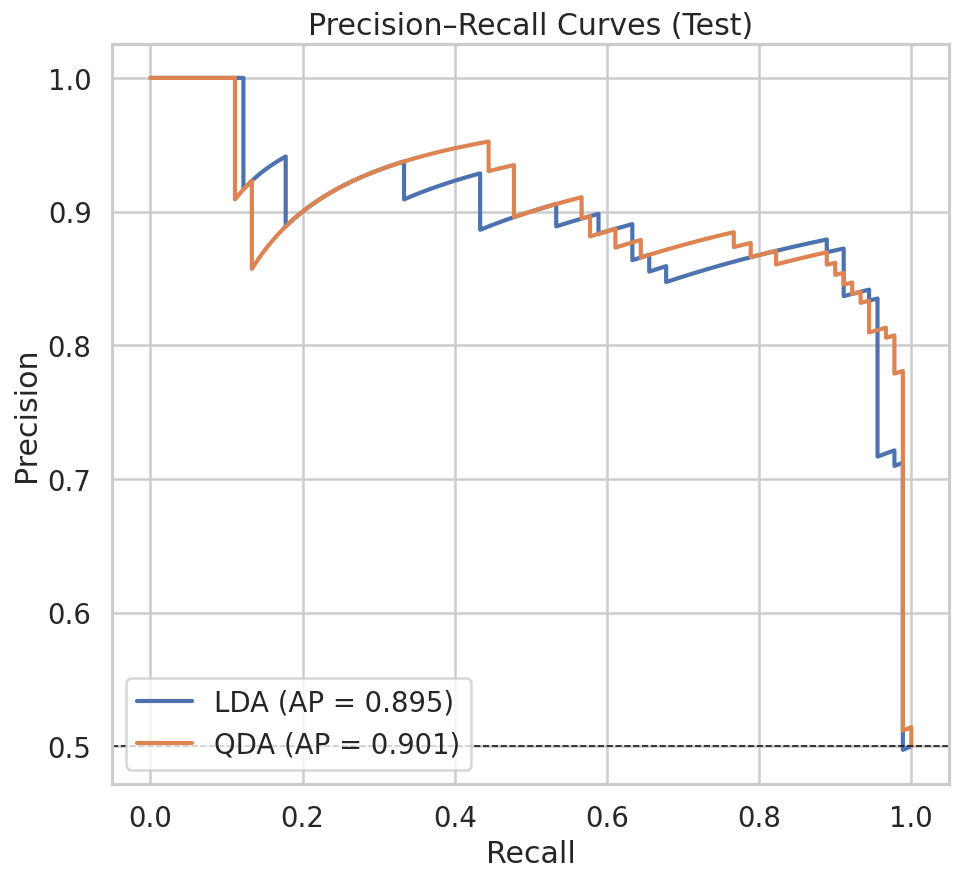

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))
for name, prob in [("LDA", y_prob_lda), ("QDA", y_prob_qda)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, lw=2.5, label=f"{name} (AP = {average_precision_score(y_test, prob):.3f})")
ax.axhline(y_test.mean(), color="k", ls="--", lw=1)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves (Test)")
ax.legend(loc="lower left")
fig.savefig(f"{OUTDIR}/09_precision_recall_curves.png")
plt.show()

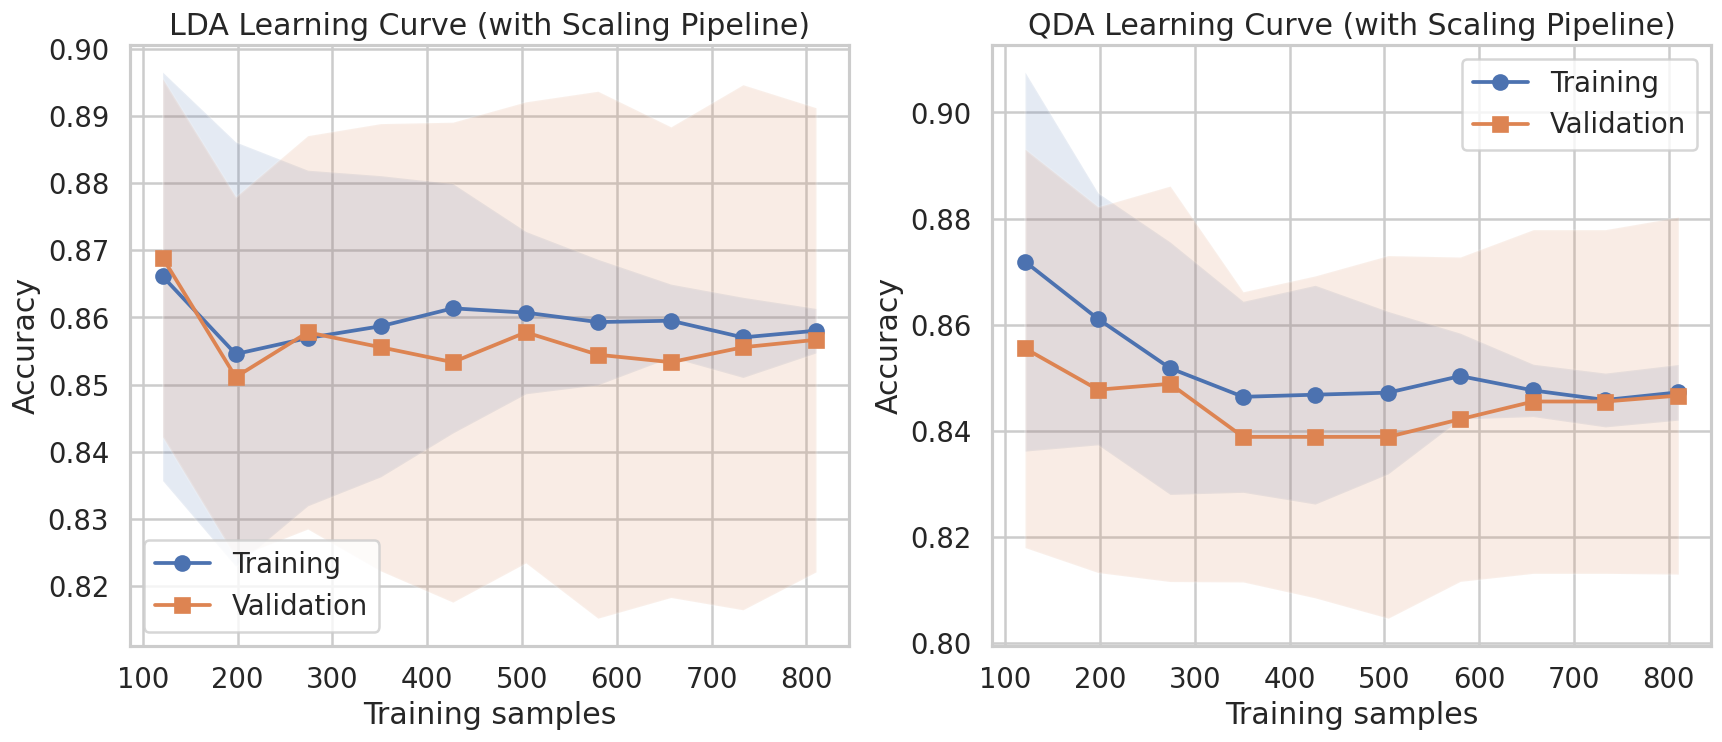

In [ ]:
from sklearn.pipeline import Pipeline

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

# Define pipelines for learning curve to ensure correct scaling within each fold
lda_lc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr")) # Using lsqr for consistency with tuning
])

qda_lc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("qda", QuadraticDiscriminantAnalysis(reg_param=1e-3)) # Keep the existing reg_param for baseline learning curve
])

for ax, (name, pipeline_model) in zip(axes, [("LDA", lda_lc_pipeline),
                                            ("QDA", qda_lc_pipeline)]):
    sizes, train_sc, val_sc = learning_curve(
        pipeline_model, X, y, cv=strat_kfold, scoring="accuracy", # Use X (unscaled) for the pipeline
        train_sizes=np.linspace(0.15, 1.0, 10), shuffle=True, random_state=RANDOM_STATE
    )
    ax.plot(sizes, train_sc.mean(axis=1), "o-", label="Training")
    ax.plot(sizes, val_sc.mean(axis=1), "s-", label="Validation")
    ax.fill_between(sizes, train_sc.mean(1) - train_sc.std(1), train_sc.mean(1) + train_sc.std(1), alpha=0.15)
    ax.fill_between(sizes, val_sc.mean(1) - val_sc.std(1), val_sc.mean(1) + val_sc.std(1), alpha=0.15)
    ax.set_title(f"{name} Learning Curve (with Scaling Pipeline)")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("Accuracy")
    ax.legend()
fig.savefig(f"{OUTDIR}/11_learning_curves_pipeline.png")
plt.show()

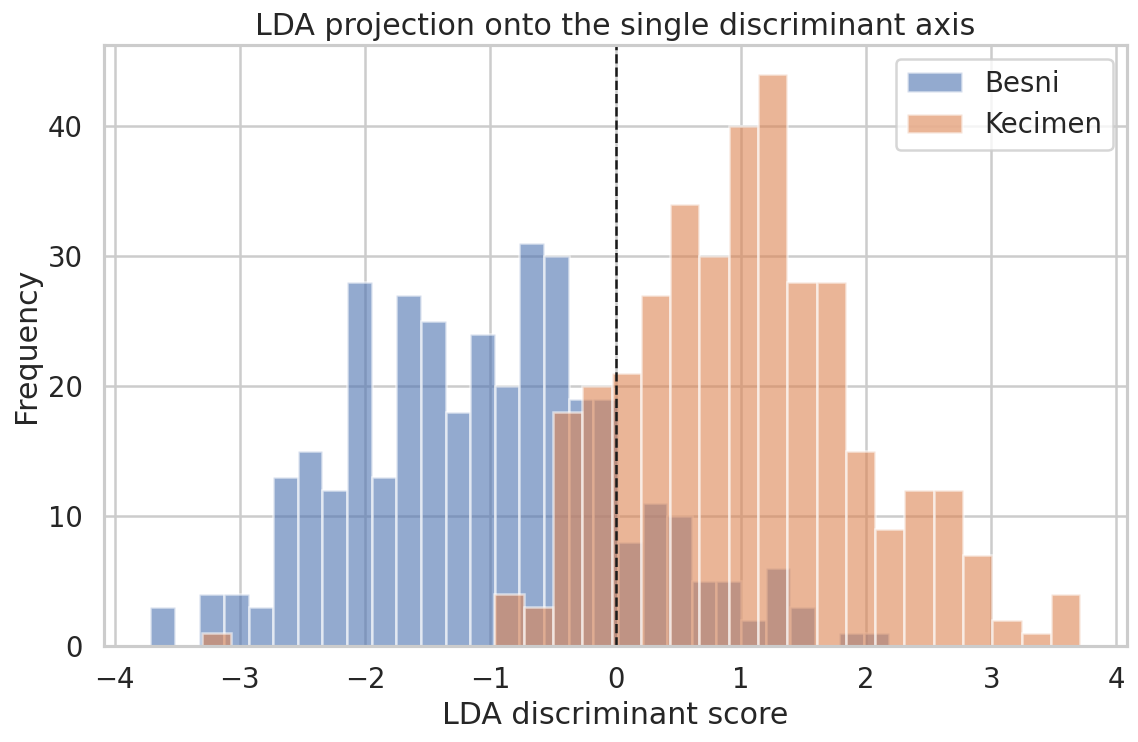

In [ ]:
lda_proj = lda.transform(X_train_s).ravel()
fig, ax = plt.subplots(figsize=(11, 6.5))
for i, c in enumerate(CLASS_NAMES):
    ax.hist(lda_proj[y_train == i], bins=30, alpha=0.6, label=c)
ax.axvline(0, color="k", ls="--", lw=1.5)
ax.set_xlabel("LDA discriminant score")
ax.set_ylabel("Frequency")
ax.set_title("LDA projection onto the single discriminant axis")
ax.legend()
fig.savefig(f"{OUTDIR}/12_lda_projection.png")
plt.show()

           Feature  LDA coefficient  Absolute
4       ConvexArea          16.6920   16.6920
0             Area         -12.7402   12.7402
6        Perimeter          -9.4979    9.4979
1  MajorAxisLength           2.7284    2.7284
3     Eccentricity          -0.7030    0.7030
2  MinorAxisLength           0.3235    0.3235
5           Extent           0.0268    0.0268


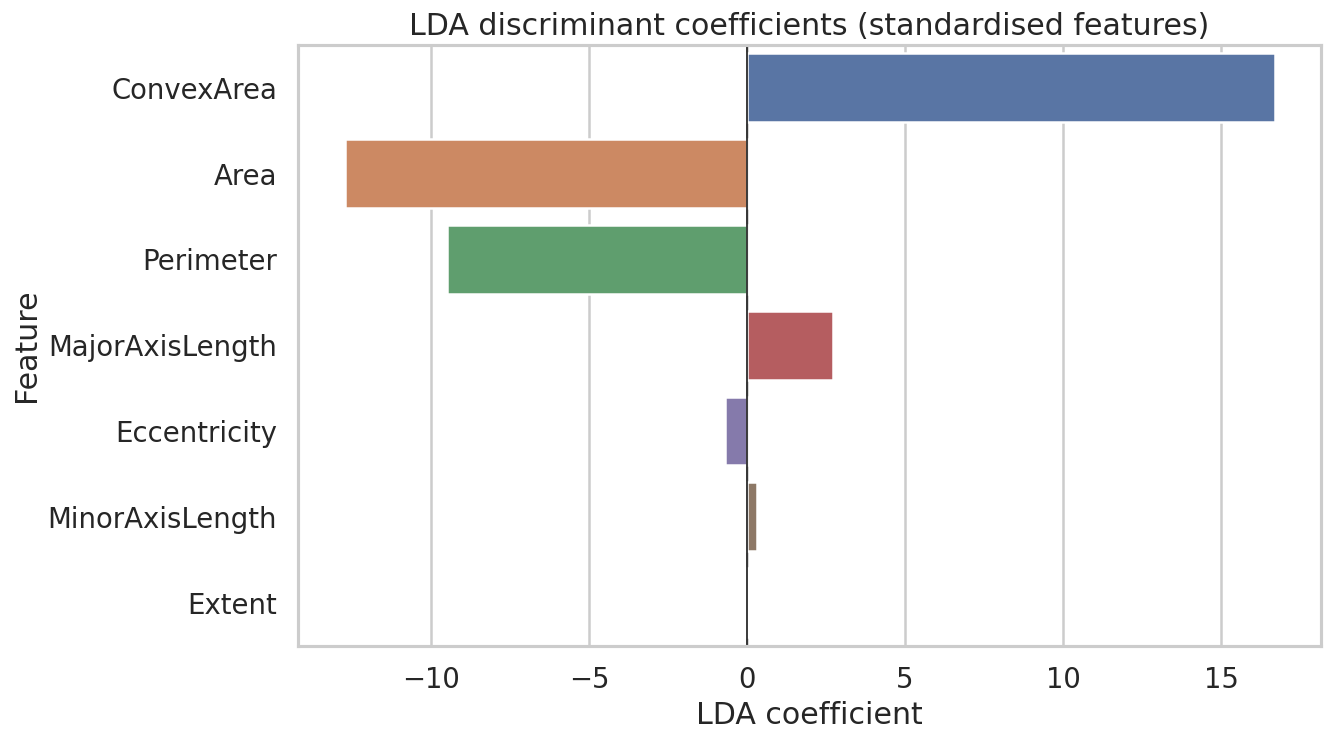

In [ ]:
coef_df = pd.DataFrame({"Feature": FEATURES, "LDA coefficient": lda.coef_.ravel()})
coef_df["Absolute"] = coef_df["LDA coefficient"].abs()
coef_df = coef_df.sort_values("Absolute", ascending=False)
print(coef_df.round(4))

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(data=coef_df, x="LDA coefficient", y="Feature", hue="Feature", legend=False, ax=ax)
ax.axvline(0, color="k", lw=1)
ax.set_title("LDA discriminant coefficients (standardised features)")
fig.savefig(f"{OUTDIR}/13_lda_coefficients.png")
plt.show()

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_p = pca.fit_transform(X_train_s)
X_test_p = pca.transform(X_test_s)
print(pca.explained_variance_ratio_, pca.explained_variance_ratio_.sum())
print(pd.DataFrame(pca.components_, columns=FEATURES, index=["PC1", "PC2"]).round(3))

lda2 = LinearDiscriminantAnalysis().fit(X_train_p, y_train)
qda2 = QuadraticDiscriminantAnalysis().fit(X_train_p, y_train)
print(accuracy_score(y_test, lda2.predict(X_test_p)), accuracy_score(y_test, qda2.predict(X_test_p)))

[0.69010867 0.20903871] 0.8991473826666159
      Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  Extent  Perimeter
PC1  0.448            0.443            0.389         0.206       0.451  -0.048      0.451
PC2  0.114           -0.138            0.374        -0.607       0.084   0.672     -0.037
0.8666666666666667 0.8666666666666667


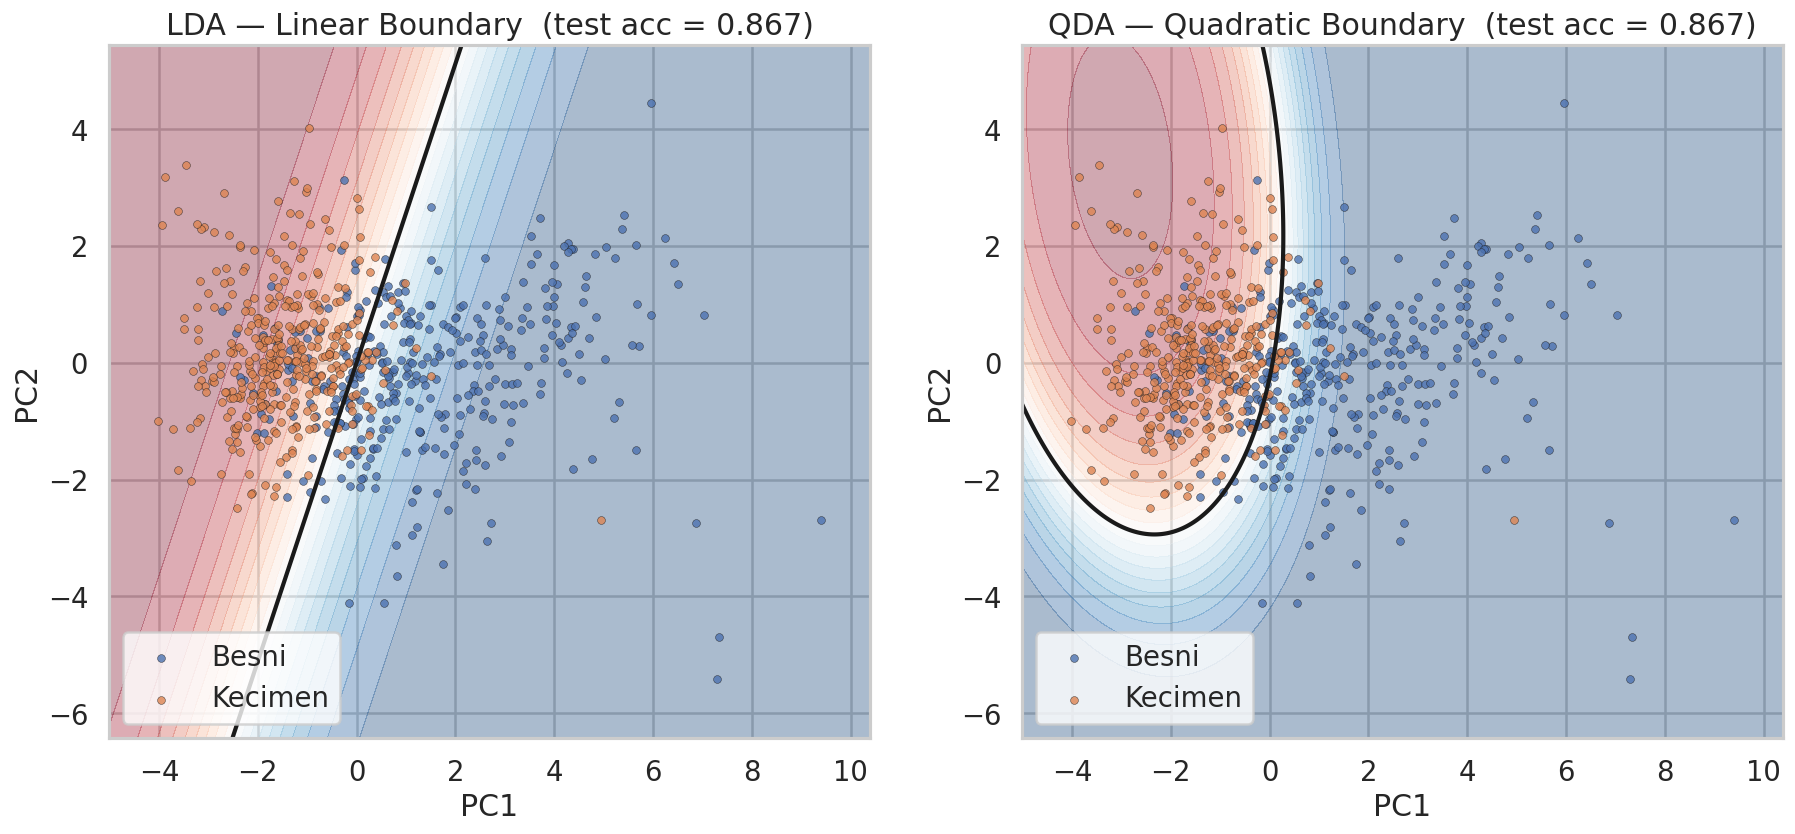

In [ ]:
xx, yy = np.meshgrid(
    np.linspace(X_train_p[:, 0].min() - 1, X_train_p[:, 0].max() + 1, 500),
    np.linspace(X_train_p[:, 1].min() - 1, X_train_p[:, 1].max() + 1, 500),
)
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
for ax, model, title in zip(axes, [lda2, qda2], ["LDA — Linear Boundary", "QDA — Quadratic Boundary"]):
    zz = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.35)
    ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2.5)
    for i, c in enumerate(CLASS_NAMES):
        ax.scatter(X_train_p[y_train == i, 0], X_train_p[y_train == i, 1], s=22, alpha=0.8,
                   edgecolor="k", linewidth=0.3, label=c)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"{title}  (test acc = {accuracy_score(y_test, model.predict(X_test_p)):.3f})")
    ax.legend()
fig.savefig(f"{OUTDIR}/14_decision_boundaries_pca.png")
plt.show()

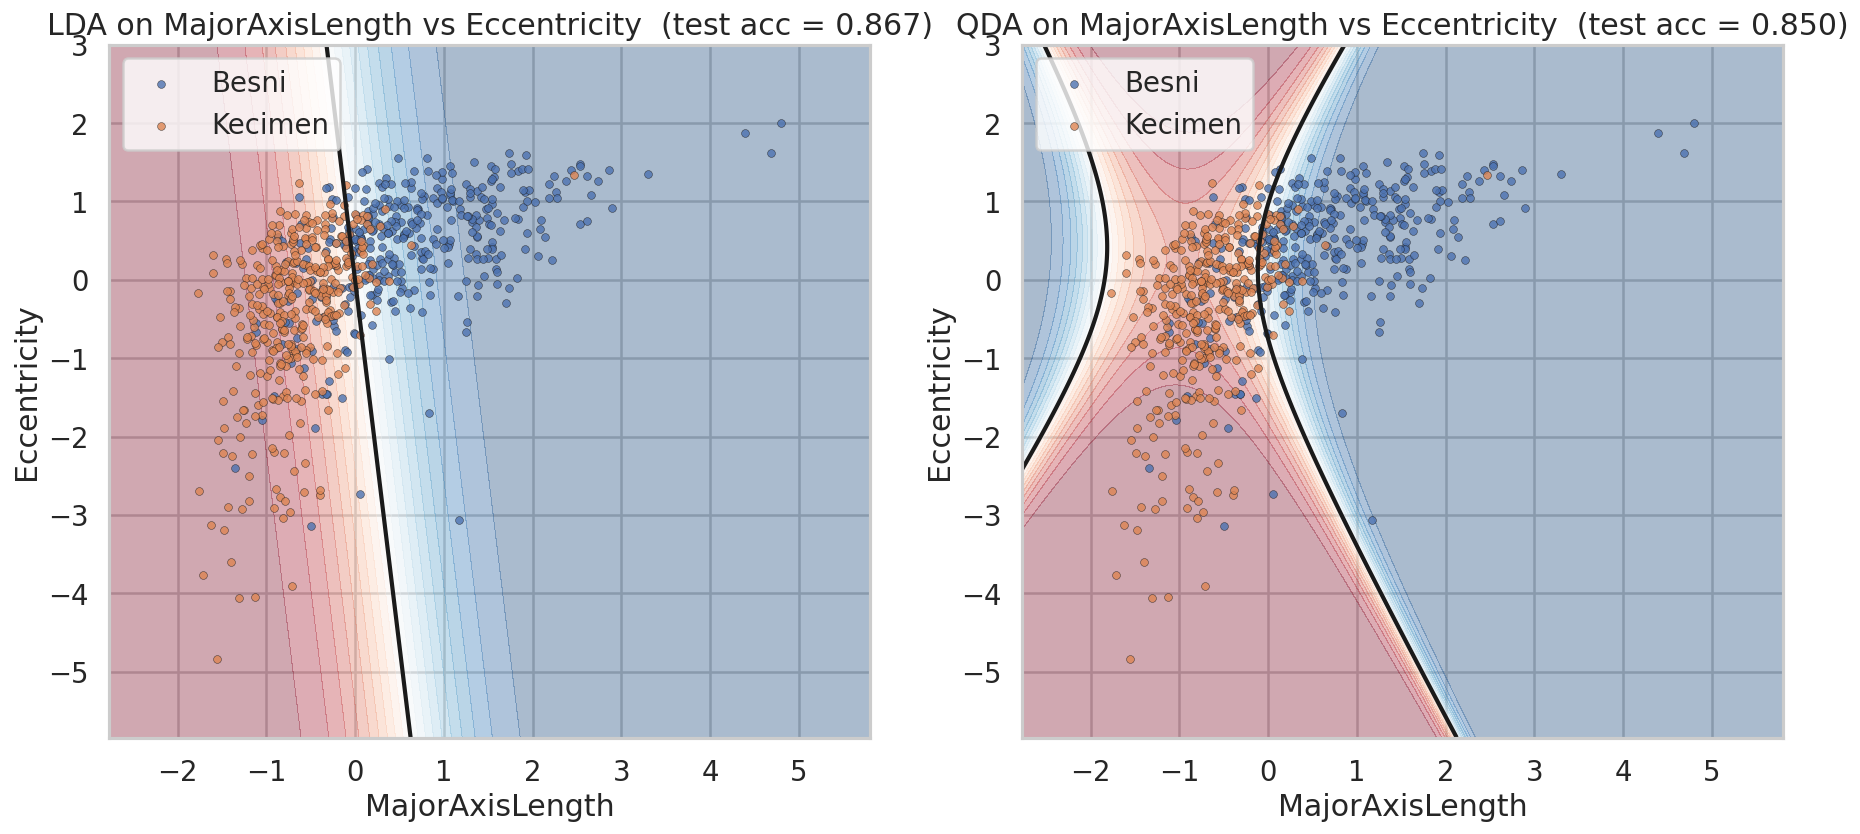

In [ ]:
PAIR = ["MajorAxisLength", "Eccentricity"]
idx = [FEATURES.index(f) for f in PAIR]
Xtr2, Xte2 = X_train_s[:, idx], X_test_s[:, idx]
lda_pair = LinearDiscriminantAnalysis().fit(Xtr2, y_train)
qda_pair = QuadraticDiscriminantAnalysis().fit(Xtr2, y_train)

xx2, yy2 = np.meshgrid(
    np.linspace(Xtr2[:, 0].min() - 1, Xtr2[:, 0].max() + 1, 500),
    np.linspace(Xtr2[:, 1].min() - 1, Xtr2[:, 1].max() + 1, 500),
)
grid2 = np.c_[xx2.ravel(), yy2.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
for ax, model, title in zip(axes, [lda_pair, qda_pair], ["LDA", "QDA"]):
    zz = model.predict_proba(grid2)[:, 1].reshape(xx2.shape)
    ax.contourf(xx2, yy2, zz, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.35)
    ax.contour(xx2, yy2, zz, levels=[0.5], colors="k", linewidths=2.5)
    for i, c in enumerate(CLASS_NAMES):
        ax.scatter(Xtr2[y_train == i, 0], Xtr2[y_train == i, 1], s=22, alpha=0.8,
                   edgecolor="k", linewidth=0.3, label=c)
    ax.set_xlabel(PAIR[0])
    ax.set_ylabel(PAIR[1])
    ax.set_title(f"{title} on {PAIR[0]} vs {PAIR[1]}  (test acc = {accuracy_score(y_test, model.predict(Xte2)):.3f})")
    ax.legend()
fig.savefig(f"{OUTDIR}/15_decision_boundaries_features.png")
plt.show()

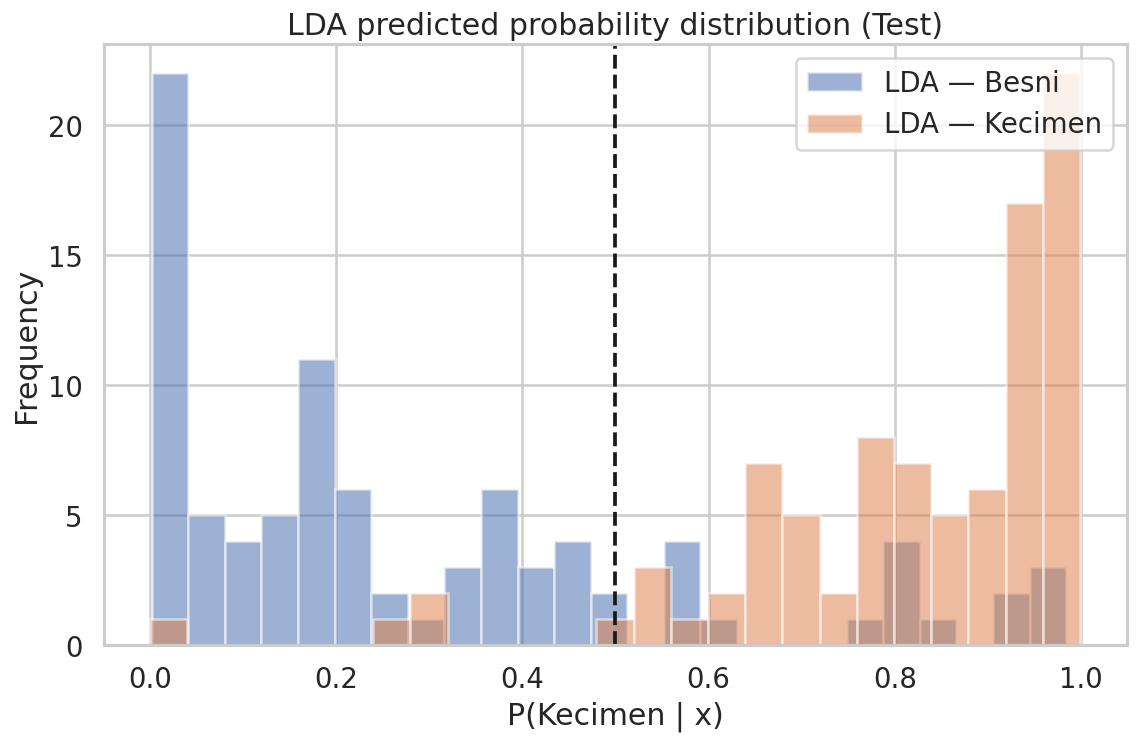

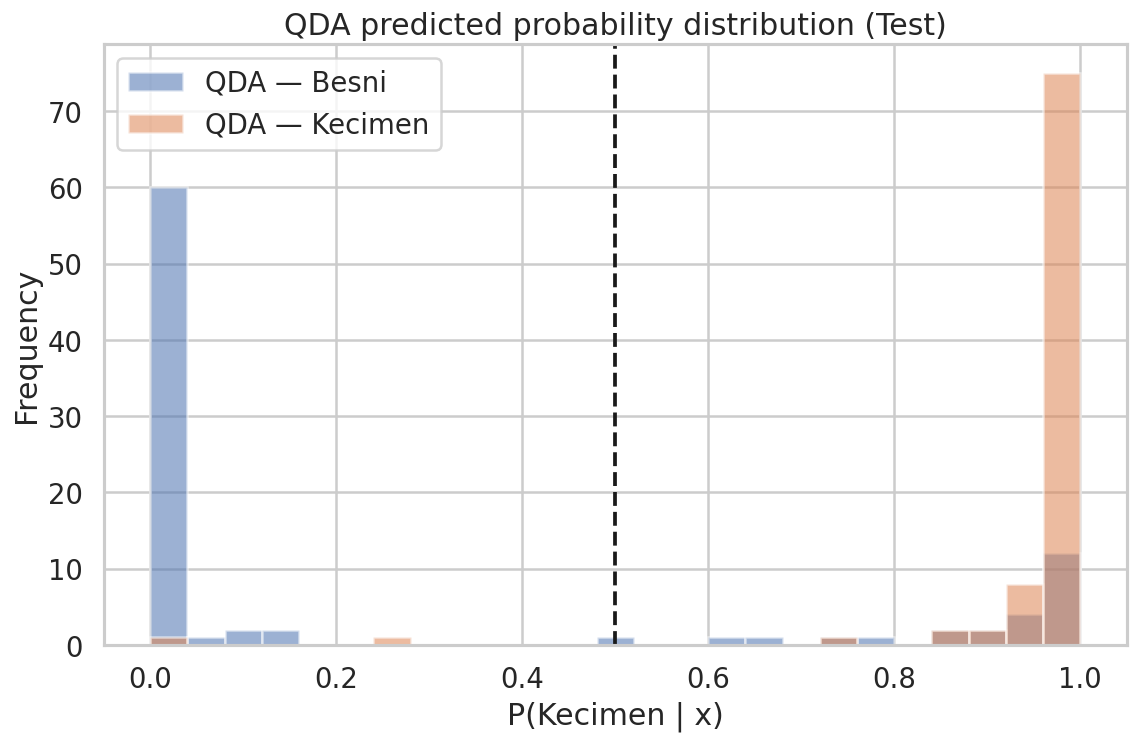

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.hist(y_prob_lda[y_test == 0], bins=25, alpha=0.55, label=f"LDA — {CLASS_NAMES[0]}")
ax.hist(y_prob_lda[y_test == 1], bins=25, alpha=0.55, label=f"LDA — {CLASS_NAMES[1]}")
ax.axvline(0.5, color="k", ls="--")
ax.set_xlabel(f"P({CLASS_NAMES[1]} | x)")
ax.set_ylabel("Frequency")
ax.set_title("LDA predicted probability distribution (Test)")
ax.legend()
fig.savefig(f"{OUTDIR}/16_lda_probability_distribution.png")
plt.show()

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.hist(y_prob_qda[y_test == 0], bins=25, alpha=0.55, label=f"QDA — {CLASS_NAMES[0]}")
ax.hist(y_prob_qda[y_test == 1], bins=25, alpha=0.55, label=f"QDA — {CLASS_NAMES[1]}")
ax.axvline(0.5, color="k", ls="--")
ax.set_xlabel(f"P({CLASS_NAMES[1]} | x)")
ax.set_ylabel("Frequency")
ax.set_title("QDA predicted probability distribution (Test)")
ax.legend()
fig.savefig(f"{OUTDIR}/17_qda_probability_distribution.png")
plt.show()

LDA Best parameters: {'lda__shrinkage': np.float64(0.05)}
LDA Best CV score: 0.8639
QDA Best parameters: {'qda__reg_param': np.float64(0.0)}
QDA Best CV score: 0.8597


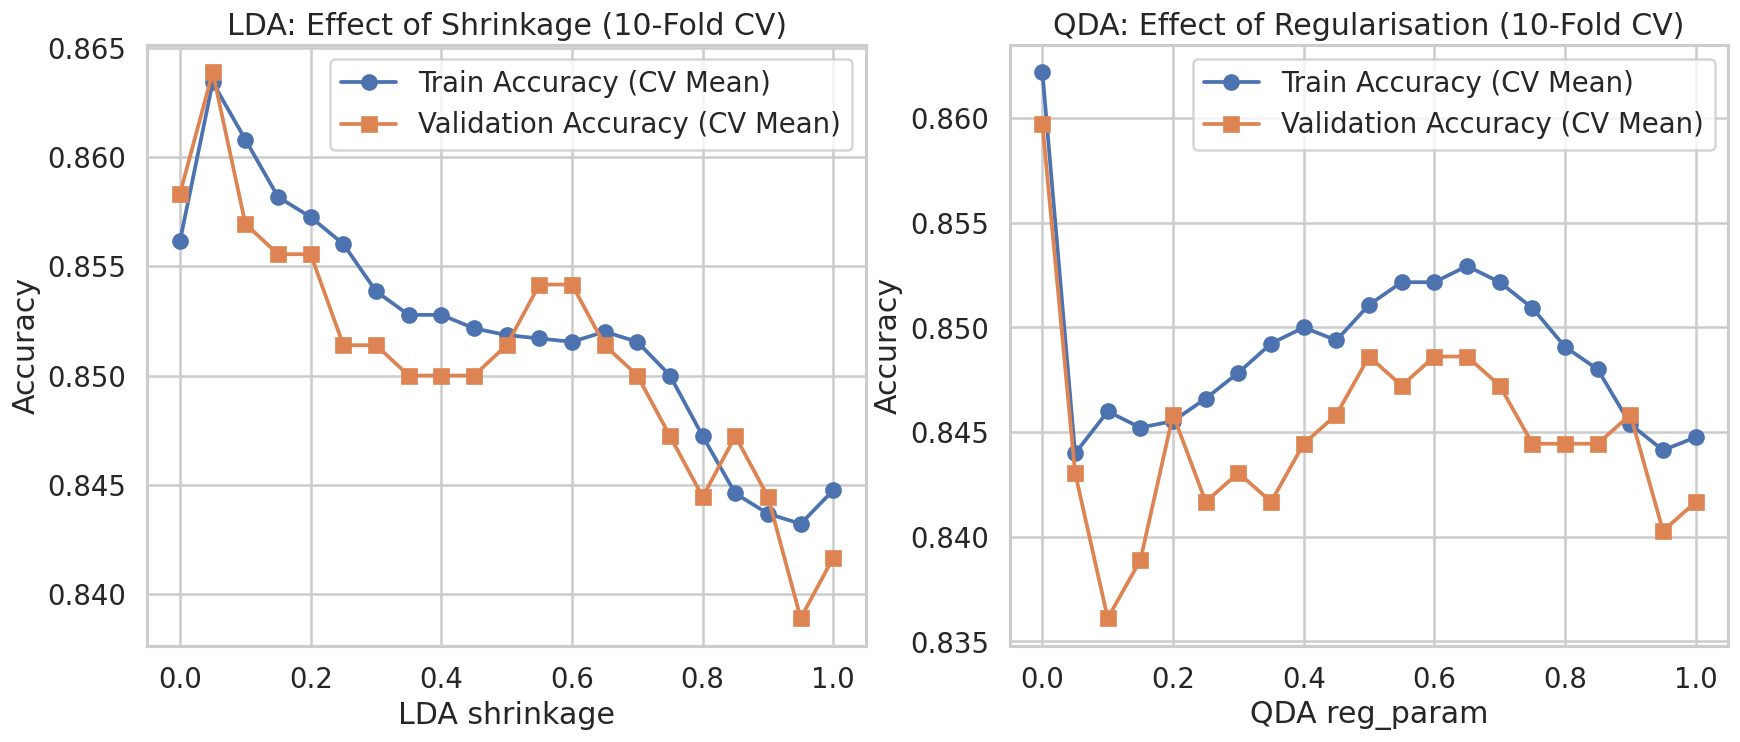

In [ ]:
from sklearn.pipeline import Pipeline

# Define pipelines for LDA and QDA with StandardScaler
lda_pipeline_tuning = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr"))
])

qda_pipeline_tuning = Pipeline([
    ("scaler", StandardScaler()),
    ("qda", QuadraticDiscriminantAnalysis())
])

# Define parameter grids for GridSearchCV
lda_param_grid = {
    "lda__shrinkage": np.linspace(0, 1, 21)
}

qda_param_grid = {
    "qda__reg_param": np.linspace(0, 1, 21)
}

# Set up StratifiedKFold for cross-validation on training data
strat_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# GridSearchCV for LDA
lda_grid = GridSearchCV(
    lda_pipeline_tuning,
    lda_param_grid,
    cv=strat_kfold,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)
lda_grid.fit(X_train, y_train) # Fit on unscaled X_train, pipeline handles scaling

# GridSearchCV for QDA
qda_grid = GridSearchCV(
    qda_pipeline_tuning,
    qda_param_grid,
    cv=strat_kfold,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)
qda_grid.fit(X_train, y_train) # Fit on unscaled X_train, pipeline handles scaling

print("LDA Best parameters:", lda_grid.best_params_)
print("LDA Best CV score:", lda_grid.best_score_.round(4))
print("QDA Best parameters:", qda_grid.best_params_)
print("QDA Best CV score:", qda_grid.best_score_.round(4))

# Extract results for plotting
lda_cv_results = pd.DataFrame(lda_grid.cv_results_)
qda_cv_results = pd.DataFrame(qda_grid.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

# Plot LDA sensitivity using CV results
axes[0].plot(lda_cv_results["param_lda__shrinkage"], lda_cv_results["mean_train_score"], "o-", label="Train Accuracy (CV Mean)")
axes[0].plot(lda_cv_results["param_lda__shrinkage"], lda_cv_results["mean_test_score"], "s-", label="Validation Accuracy (CV Mean)")
axes[0].set_xlabel("LDA shrinkage")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("LDA: Effect of Shrinkage (10-Fold CV)")
axes[0].legend()

# Plot QDA sensitivity using CV results
axes[1].plot(qda_cv_results["param_qda__reg_param"], qda_cv_results["mean_train_score"], "o-", label="Train Accuracy (CV Mean)")
axes[1].plot(qda_cv_results["param_qda__reg_param"], qda_cv_results["mean_test_score"], "s-", label="Validation Accuracy (CV Mean)")
axes[1].set_xlabel("QDA reg_param")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("QDA: Effect of Regularisation (10-Fold CV)")
axes[1].legend()

fig.savefig(f"{OUTDIR}/18_hyperparameter_sensitivity_cv.png")
plt.show()

         LDA     QDA
mean  0.8583  0.8546
std   0.0281  0.0246
min   0.7778  0.8056
max   0.9000  0.9056


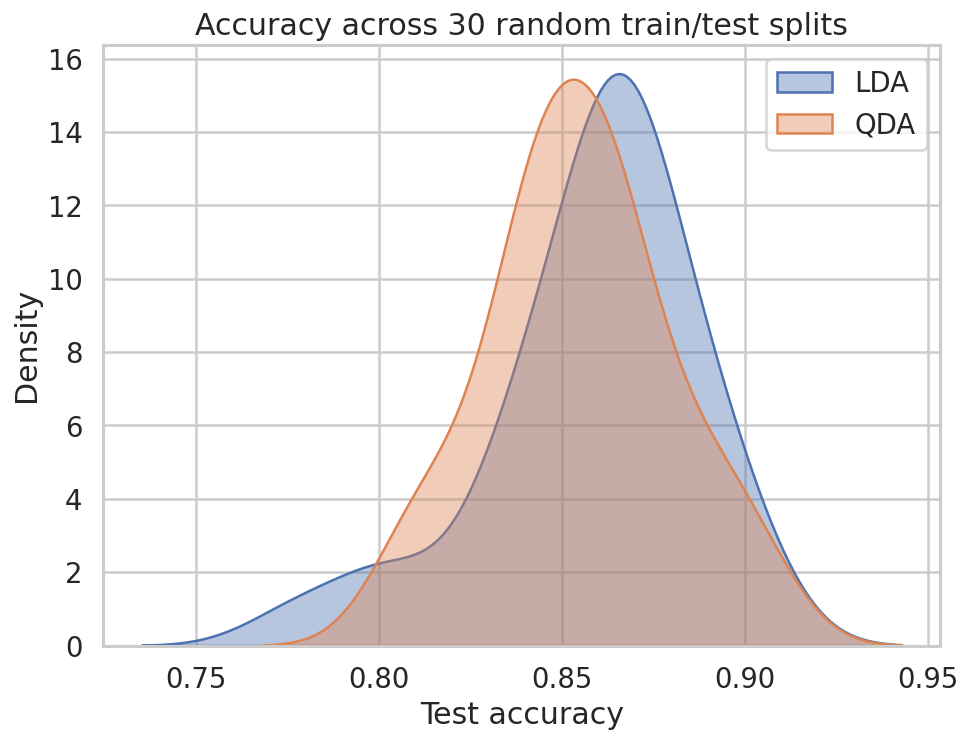

In [ ]:
seeds = range(30)
stab_rows = []
for s in seeds:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, stratify=y, random_state=s)
    sc = StandardScaler().fit(Xtr)
    Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    stab_rows.append({
        "seed": s,
        "LDA": accuracy_score(yte, LinearDiscriminantAnalysis().fit(Xtr, ytr).predict(Xte)),
        "QDA": accuracy_score(yte, QuadraticDiscriminantAnalysis().fit(Xtr, ytr).predict(Xte)),
    })
stab_df = pd.DataFrame(stab_rows)
print(stab_df[["LDA", "QDA"]].agg(["mean", "std", "min", "max"]).round(4))

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.kdeplot(stab_df["LDA"], fill=True, alpha=0.4, label="LDA", ax=ax)
sns.kdeplot(stab_df["QDA"], fill=True, alpha=0.4, label="QDA", ax=ax)
ax.set_xlabel("Test accuracy")
ax.set_title("Accuracy across 30 random train/test splits")
ax.legend()
fig.savefig(f"{OUTDIR}/19_split_stability.png")
plt.show()

In [ ]:
lda_best_cv_mean_accuracy = lda_grid.best_score_
qda_best_cv_mean_accuracy = qda_grid.best_score_

# Find the std deviation for the best estimator from cv_results
lda_best_idx = lda_grid.best_index_
qda_best_idx = qda_grid.best_index_

lda_best_cv_std_accuracy = lda_grid.cv_results_['std_test_score'][lda_best_idx]
qda_best_cv_std_accuracy = qda_grid.cv_results_['std_test_score'][qda_best_idx]


final_summary = pd.DataFrame({
    "Metric": ["Test Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "10-Fold CV Accuracy (mean)", "10-Fold CV Accuracy (std)"],
    "LDA (Tuned)": [ # Updated model name for clarity
        accuracy_score(y_test, y_pred_lda), precision_score(y_test, y_pred_lda),
        recall_score(y_test, y_pred_lda), f1_score(y_test, y_pred_lda),
        roc_auc_score(y_test, y_prob_lda), lda_best_cv_mean_accuracy, lda_best_cv_std_accuracy,
    ],
    "QDA (Tuned)": [ # Updated model name for clarity
        accuracy_score(y_test, y_pred_qda), precision_score(y_test, y_pred_qda),
        recall_score(y_test, y_pred_qda), f1_score(y_test, y_pred_qda),
        roc_auc_score(y_test, y_prob_qda), qda_best_cv_mean_accuracy, qda_best_cv_std_accuracy,
    ],
})
# Updated column name for consistency
final_summary["Difference (QDA (Tuned) - LDA (Tuned))"] = final_summary["QDA (Tuned)"] - final_summary["LDA (Tuned)"]
print(final_summary.round(4).to_string(index=False))
final_summary.round(4).to_csv("results_final_summary_tuned.csv", index=False) # Updated filename
# Ensure the printed list of figures reflects all new filenames
updated_figure_names = [
    '01_feature_distributions.png', '02_boxplots.png', '03_correlation_heatmap.png',
    '04_pairplot.png', '05_covariance_matrices.png', '06_confusion_matrices.png',
    '07_confusion_matrices_normalised.png', '08_roc_curves.png', '09_precision_recall_curves.png',
    '10_cv_accuracy_boxplot_tuned.png', '11_learning_curves_pipeline.png', '12_lda_projection.png',
    '13_lda_coefficients.png', '14_decision_boundaries_pca.png', '15_decision_boundaries_features.png',
    '16_lda_probability_distribution.png', '17_qda_probability_distribution.png',
    '18_hyperparameter_sensitivity_cv.png', '19_split_stability.png'
]
print(sorted(updated_figure_names))

                    Metric  LDA (Tuned)  QDA (Tuned)  Difference (QDA (Tuned) - LDA (Tuned))
             Test Accuracy       0.8833       0.8556                                 -0.0278
                 Precision       0.8416       0.7857                                 -0.0559
                    Recall       0.9444       0.9778                                  0.0333
                        F1       0.8901       0.8713                                 -0.0188
                   ROC-AUC       0.9144       0.9225                                  0.0080
10-Fold CV Accuracy (mean)       0.8639       0.8597                                 -0.0042
 10-Fold CV Accuracy (std)       0.0447       0.0191                                 -0.0256
['01_feature_distributions.png', '02_boxplots.png', '03_correlation_heatmap.png', '04_pairplot.png', '05_covariance_matrices.png', '06_confusion_matrices.png', '07_confusion_matrices_normalised.png', '08_roc_curves.png', '09_precision_recall_curves.png', '

In [ ]:
import shutil
shutil.make_archive("lda_qda_figures", "zip", OUTDIR)
try:
    from google.colab import files
    files.download("lda_qda_figures.zip")
except ImportError:
    pass
print(os.path.getsize("lda_qda_figures.zip"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

9250280
